# Part 1 — Data Wiring and Serial-Radiograph Alert-Burden Foundations

**Working study title:** Decomposing Serial-Radiograph Alert Burden in Chest X-ray AI:
False, Redundant, and Actionable-New Alerts

Part 1 builds and audits the data substrate only. No classifier is trained, no
discrimination or calibration metric is computed, and no alert policy is evaluated
here. Everything produced in this notebook is metadata-derived and cheap to recompute.

---

## 1. Study question, estimand, and design boundaries

### 1.1 Question

When a simulated chest-radiograph AI clinical decision support (CDS) system is run over
**ordered within-patient image sequences** rather than over independent images, how does
the total volume of fired alerts decompose into alerts that are wrong, alerts that
restate something already seen in that patient's available sequence, and alerts that
surface a finding not previously present in that sequence?

### 1.2 Target estimand (to be estimated in later parts, not here)

For a fixed decision threshold `t`, over image-pathology pairs in the analysis cohort:

- **False alert** — model fires, reference label is negative.
- **Redundant alert** — model fires, reference label is positive, and the same pathology
  was already positive earlier in that patient's *available* sequence.
- **Actionable-new alert** — model fires, reference label is positive, and the pathology
  was not positive at any earlier point in that patient's *available* sequence.

The three categories are mutually exclusive and exhaustive among fired alerts **within
the pre-specified sequence-eligible analytic cohort**. Rows outside that cohort have no
interpretable history and are therefore unclassifiable rather than assigned a default.

### 1.3 Two redundancy constructs, not one

This is a correction to the naive design and it matters. A **deployed** suppression
policy cannot consult reference labels; it can only consult what the model itself
previously emitted. Two distinct constructs therefore exist and must be reported
separately:

| Construct | History source | Interpretation |
|---|---|---|
| `label_history` | prior reference labels | Retrospective/oracle. Answers "how much of the fired burden repeats a previously positive label in the available sequence?" |
| `prediction_history` | prior model firings at the same threshold | Deployable. Answers "how much burden could a suppression rule remove using the model's own prior alert history?" |

The gap between the two is itself a reportable quantity. It measures the observed
disconnect between prior positive-label history and prior model-alert history within the
available sequence, and it reflects a mixture of model sensitivity, threshold choice,
weak-label instability, and incomplete observed history. It is **not** attributable to
any single one of those causes, and must not be described as though it were.
Part 1 builds the schema for both families. Part 2 populates them.

### 1.4 Design boundaries that constrain every downstream claim

1. **`Follow-up #` is an ordinal encounter index, not calendar time.** ChestX-ray14 ships
   no timestamps. No result may be expressed per day, week, or month, and no statement
   about onset, duration, progression rate, or time-to-event is licensed.
2. **Labels are report-derived weak labels.** They are NLP extractions from radiology
   reports, not adjudicated image-level ground truth.
3. **Sequences are left-truncated and right-censored.** Only radiographs acquired at the
   contributing institution and released in this corpus are visible. Imaging performed
   before the first available study, or elsewhere, is invisible. Consequently
   "first observed in the available sequence" systematically **overcounts** true first
   presentation, and this bias is largest at ordinal position 1.
4. **Index encounters are degenerate for history.** At `sequence_position_ordinal == 1`
   every positive label is, by construction, first observed *within the available
   sequence*. That is a property of the observation window, not of the patient. Index
   and follow-up encounters must therefore be reported separately and never pooled into
   a single first-observed fraction. This notebook builds the flag that enforces the split.
5. **The category named `first_observed_positive_alert` carries no clinical claim.** The
   manuscript shorthand "actionable-new" refers to exactly this operational definition:
   a fired alert on a positive weak label with no earlier positive label in the available
   sequence. It does not assert incident disease, changed management, benefit, or safety.
6. **Heavy imagers dominate image-level counts.** Any burden quantity must be reported
   both per image and per patient, because a small number of frequently-imaged patients
   contribute a disproportionate share of images and are systematically sicker.
7. The eventual study is a retrospective simulation. It is not evidence about real
   clinician behaviour, workload, or clinical outcome.

### 1.5 What Part 1 delivers

A linked, audited, fingerprinted image-metadata table; a parsed multi-label matrix with
an explicit integrity audit; ordinal within-patient sequences with documented
eligibility rules; a long-format image-pathology label-transition table; validated
schemas and unexecuted functions for the future alert-burden computation; and a set of
audit tables and figures written to disk for reuse by later parts.

## 2. Environment, configuration, and reproducibility

Edit the paths in the configuration cell to match your machine. Everything else has a
working default.

**A note on `FAST_MODE`.** It gates only the optional image-touching steps (visual QC and
embedding extraction). It deliberately does **not** subsample the metadata analysis:
all coverage, label, sequence and transition tables are always computed over the full
corpus, because doing otherwise would silently corrupt the audit numbers that later
parts depend on. The full metadata pipeline runs in well under a minute on a laptop CPU.

In [4]:
from __future__ import annotations

import gc
import hashlib
import json
import os
import platform
import random
import re
import sys
import time
import warnings
from dataclasses import dataclass, asdict
from datetime import datetime, timezone
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("once", category=UserWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

# =============================== CONFIGURATION ===============================
# Windows paths: use a raw string or forward slashes.
DATA_ROOT: Path = Path(r"C:\Users\kruta\Downloads\NIH Chest X-rays")

# Leave as None to auto-discover inside DATA_ROOT.
METADATA_CSV: Optional[Path] = None          # e.g. DATA_ROOT / "Data_Entry_2017.csv"
IMAGE_ROOT: Optional[Path] = None            # e.g. DATA_ROOT  (images_001..012 live here)
BBOX_CSV: Optional[Path] = None              # e.g. DATA_ROOT / "BBox_List_2017.csv"
GOOGLE_LABELS_PATH: Optional[Path] = None    # optional adjudicated-label CSV
OFFICIAL_SPLIT_DIR: Optional[Path] = None    # holds train_val_list.txt / test_list.txt

OUTPUT_DIR: Path = Path("./part1_outputs").resolve()

RANDOM_SEED: int = 42

# Gates only the optional image-touching steps. Metadata analysis always runs in full.
FAST_MODE: bool = True

MAX_EDA_PATIENTS_FOR_SEQUENCE_AUDIT: int = 10
N_VISUAL_QC_IMAGES: int = 8
DEMO_EMBEDDING_N: int = 32
MAX_EMBEDDING_IMAGES_WITHOUT_CONFIRMATION: int = 1000
CONFIRM_LARGE_EMBEDDING_RUN: bool = False

ALLOW_MODEL_DOWNLOAD: bool = False
DEFAULT_BACKBONE: str = "resnet50_imagenet"
CPU_BATCH_SIZE: int = 16
NUM_WORKERS: int = 0                          # 0 is the only portable default on Windows

SEQUENCE_POSITION_CAP_K: int = 10             # final ">= K" bin in position plots
IMAGE_EXTENSIONS: Tuple[str, ...] = (".png", ".jpg", ".jpeg")

PATHOLOGIES: Tuple[str, ...] = (
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration", "Mass", "Nodule",
    "Pneumonia", "Pneumothorax", "Consolidation", "Edema", "Emphysema", "Fibrosis",
    "Pleural_Thickening", "Hernia",
)
NO_FINDING_TOKEN: str = "No Finding"
# =============================================================================

# ------------------------------- seeding -------------------------------------
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)
try:                                            # torch is optional in Part 1
    import torch
    torch.manual_seed(RANDOM_SEED)
    torch.use_deterministic_algorithms(False)   # CPU determinism is sufficient here
    _TORCH_AVAILABLE = True
except Exception:
    _TORCH_AVAILABLE = False

sns.set_theme(style="whitegrid", palette="colorblind", font_scale=0.95)
matplotlib.rcParams["figure.dpi"] = 110
matplotlib.rcParams["savefig.dpi"] = 200
matplotlib.rcParams["savefig.bbox"] = "tight"

TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"
CACHE_DIR = OUTPUT_DIR / "cache"
LOGS_DIR = OUTPUT_DIR / "logs"

print("Python      :", sys.version.split()[0], "|", platform.system(), platform.release())
print("pandas      :", pd.__version__)
print("numpy       :", np.__version__)
print("torch       :", torch.__version__ if _TORCH_AVAILABLE else "not installed (optional)")
print("seed        :", RANDOM_SEED)
print("FAST_MODE   :", FAST_MODE, "(gates optional image steps only)")
print("DATA_ROOT   :", DATA_ROOT)
print("OUTPUT_DIR  :", OUTPUT_DIR)

Python      : 3.11.5 | Windows 10
pandas      : 2.3.3
numpy       : 1.24.4
torch       : not installed (optional)
seed        : 42
FAST_MODE   : True (gates optional image steps only)
DATA_ROOT   : C:\Users\kruta\Downloads\NIH Chest X-rays
OUTPUT_DIR  : C:\Users\kruta\Downloads\part1_outputs


In [5]:
# ----------------------------- reusable helpers ------------------------------

def ensure_dir(path: Path) -> Path:
    """Create `path` (and parents) if absent and return it."""
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


for _d in (OUTPUT_DIR, TABLES_DIR, FIGURES_DIR, CACHE_DIR, LOGS_DIR):
    ensure_dir(_d)

_SAVED_TABLES: List[str] = []
_SAVED_FIGURES: List[str] = []


def save_table(df: pd.DataFrame, name: str, index: bool = False) -> Path:
    """Write `df` to OUTPUT_DIR/tables/<name>.csv and record it for the audit checklist."""
    if not name.endswith(".csv"):
        name += ".csv"
    out = TABLES_DIR / name
    df.to_csv(out, index=index)
    if name not in _SAVED_TABLES:
        _SAVED_TABLES.append(name)
    print(f"  table saved  -> {out.name}  ({len(df):,} rows x {df.shape[1]} cols)")
    return out


def save_figure(fig: plt.Figure, name: str, close: bool = False) -> Path:
    """Write `fig` to OUTPUT_DIR/figures/<name>.png and record it."""
    if not name.endswith(".png"):
        name += ".png"
    out = FIGURES_DIR / name
    fig.savefig(out)
    if name not in _SAVED_FIGURES:
        _SAVED_FIGURES.append(name)
    print(f"  figure saved -> {out.name}")
    if close:
        plt.close(fig)
    return out


class print_runtime_summary:
    """Context manager printing wall-clock duration of a labelled block.

    Example
    -------
    >>> with print_runtime_summary("index images"):
    ...     idx = index_image_files(root)
    """

    def __init__(self, label: str) -> None:
        self.label = label

    def __enter__(self) -> "print_runtime_summary":
        self._t0 = time.perf_counter()
        print(f"[start] {self.label}")
        return self

    def __exit__(self, *exc) -> bool:
        dt = time.perf_counter() - self._t0
        unit = f"{dt:.1f} s" if dt < 90 else f"{dt/60:.1f} min"
        print(f"[done ] {self.label}  ({unit})")
        return False


def warn_if_large_task(n_items: int, seconds_per_item: float, label: str,
                       soft_limit_seconds: float = 120.0) -> float:
    """Print an estimated workload for `n_items` and warn past `soft_limit_seconds`.

    Returns the estimated duration in seconds so callers can branch on it.
    """
    est = n_items * seconds_per_item
    shown = f"{est:.0f} s" if est < 90 else f"{est/60:.1f} min"
    print(f"[estimate] {label}: {n_items:,} items ~ {shown} on this CPU")
    if est > soft_limit_seconds:
        warnings.warn(
            f"{label} is estimated at {shown}. Reduce the item count or set an explicit "
            f"confirmation flag before running.", UserWarning, stacklevel=2,
        )
    return est


def file_fingerprint(path: Path, hash_head_bytes: int = 1 << 20) -> Dict[str, object]:
    """Cheap, reproducible fingerprint of a file.

    Hashes only the first `hash_head_bytes` plus name and size, so this stays fast on
    multi-gigabyte corpora and never requires reading every image.
    """
    path = Path(path)
    if not path.exists():
        return {"path": str(path), "exists": False, "size_bytes": None,
                "mtime_utc": None, "head_sha1": None}
    st = path.stat()
    h = hashlib.sha1()
    h.update(path.name.encode("utf-8"))
    h.update(str(st.st_size).encode("utf-8"))
    with open(path, "rb") as fh:
        h.update(fh.read(hash_head_bytes))
    return {
        "path": str(path),
        "exists": True,
        "size_bytes": int(st.st_size),
        "mtime_utc": datetime.fromtimestamp(st.st_mtime, tz=timezone.utc).isoformat(),
        "head_sha1": h.hexdigest(),
    }


def dataframe_fingerprint(df: pd.DataFrame, cols: Optional[Sequence[str]] = None) -> str:
    """Order-insensitive-to-columns, order-sensitive-to-rows SHA1 of a data frame.

    Used to prove that later parts consumed the same table Part 1 produced.
    """
    use = list(cols) if cols else list(df.columns)
    sub = df.loc[:, use]
    h = hashlib.sha1()
    h.update("|".join(use).encode("utf-8"))
    h.update(str(sub.shape).encode("utf-8"))
    h.update(pd.util.hash_pandas_object(sub, index=False).values.tobytes())
    return h.hexdigest()


RUN_MANIFEST: Dict[str, object] = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "random_seed": RANDOM_SEED,
    "fast_mode": FAST_MODE,
    "python": sys.version.split()[0],
    "platform": f"{platform.system()} {platform.release()}",
    "pandas": pd.__version__,
    "numpy": np.__version__,
}
print("Helpers ready. Output folders created under:", OUTPUT_DIR)

Helpers ready. Output folders created under: C:\Users\kruta\Downloads\part1_outputs


## 3. Locate NIH metadata and index image files

The release layout varies between mirrors. Some ship `images/*.png`; the official
download ships twelve archives that expand to `images_001/images/*.png` through
`images_012/images/*.png`. The indexer below makes no assumption about folder position:
it walks recursively, keys on **filename**, and never opens an image.

Duplicate filenames across folders are a real hazard on partially re-extracted archives,
so they are detected and reported rather than silently deduplicated.

In [6]:
def find_metadata_csv(data_root: Path, explicit: Optional[Path] = None) -> Path:
    """Locate the ChestX-ray14 metadata table, failing informatively."""
    if explicit is not None:
        p = Path(explicit)
        if p.exists():
            return p
        raise FileNotFoundError(f"METADATA_CSV was set to {p} but that file does not exist.")

    root = Path(data_root)
    if not root.exists():
        parent = root.parent
        nearby = sorted(d.name for d in parent.iterdir() if d.is_dir())[:20] \
            if parent.exists() else []
        raise FileNotFoundError(
            f"DATA_ROOT does not exist: {root}\n"
            f"Parent {'exists' if parent.exists() else 'also missing'}. "
            f"Folders in parent: {nearby}\n"
            "Check the Windows username and folder name in the Cell 1 configuration."
        )

    patterns = ["Data_Entry_2017*.csv", "Data_Entry_2017*.csv.gz",
                "Data_Entry_2017*.xls", "Data_Entry_2017*.xlsx",
                "Data_Entry*.*", "*data_entry*.*"]
    for pat in patterns:
        hits = sorted(h for h in root.rglob(pat)
                      if h.is_file() and not h.name.startswith("~$"))
        if hits:
            if len(hits) > 1:
                warnings.warn(f"Multiple candidates; using {hits[0].name}. "
                              f"Others: {[h.name for h in hits[1:]]}", UserWarning)
            return hits[0]

    top = sorted(p.name for p in root.iterdir())[:25]
    raise FileNotFoundError(
        f"DATA_ROOT exists ({root}) but contains no Data_Entry file.\n"
        f"Top-level contents: {top}"
    )


def find_image_root(data_root: Path, explicit: Optional[Path] = None) -> Path:
    """Return the directory beneath which all image folders live.

    Prefers a parent that contains images_XXX folders; otherwise falls back to data_root.
    """
    if explicit is not None:
        p = Path(explicit)
        if p.exists():
            return p
        raise FileNotFoundError(f"IMAGE_ROOT was set to {p} but that path does not exist.")

    root = Path(data_root)
    archive_dirs = sorted(d for d in root.glob("images_*") if d.is_dir())
    if archive_dirs:
        print(f"  found {len(archive_dirs)} archive folders: "
              f"{archive_dirs[0].name} .. {archive_dirs[-1].name}")
        return root
    if (root / "images").is_dir():
        return root / "images"
    return root


def index_image_files(image_root: Path,
                      extensions: Sequence[str] = IMAGE_EXTENSIONS) -> pd.DataFrame:
    """Recursively index image files without opening any of them.

    Returns one row per file on disk with columns:
    `Image Index`, `image_path`, `image_extension`, `image_parent`.
    Matching is case-insensitive on the extension.
    """
    exts = {e.lower() for e in extensions}
    names: List[str] = []
    paths: List[str] = []
    parents: List[str] = []
    exts_found: List[str] = []

    for dirpath, _dirnames, filenames in os.walk(image_root):
        for fn in filenames:
            ext = os.path.splitext(fn)[1].lower()
            if ext in exts:
                names.append(fn)
                paths.append(os.path.join(dirpath, fn))
                parents.append(os.path.basename(dirpath))
                exts_found.append(ext)

    idx = pd.DataFrame({
        "Image Index": names,
        "image_path": paths,
        "image_parent": parents,
        "image_extension": exts_found,
    })
    idx["image_path_duplicate"] = idx.duplicated("image_path", keep=False)
    idx["image_index_duplicate"] = idx.duplicated("Image Index", keep=False)
    return idx


with print_runtime_summary("locate metadata and index images"):
    META_PATH = find_metadata_csv(DATA_ROOT, METADATA_CSV)
    IMG_ROOT = find_image_root(DATA_ROOT, IMAGE_ROOT)
    print(f"  metadata : {META_PATH}")
    print(f"  image root: {IMG_ROOT}")
    image_index = index_image_files(IMG_ROOT)

print(f"\nImage files indexed : {len(image_index):,}")
print(f"Unique filenames    : {image_index['Image Index'].nunique():,}")
print(f"Duplicate filenames : {int(image_index['image_index_duplicate'].sum()):,}")
print("\nFiles per folder (top 15):")
print(image_index["image_parent"].value_counts().head(15).to_string())

RUN_MANIFEST["metadata_file"] = file_fingerprint(META_PATH)
RUN_MANIFEST["image_root"] = str(IMG_ROOT)
RUN_MANIFEST["n_image_files_indexed"] = int(len(image_index))

[start] locate metadata and index images
  found 12 archive folders: images_001 .. images_012
  metadata : C:\Users\kruta\Downloads\NIH Chest X-rays\Data_Entry_2017.csv
  image root: C:\Users\kruta\Downloads\NIH Chest X-rays
[done ] locate metadata and index images  (6.8 s)

Image files indexed : 112,120
Unique filenames    : 112,120
Duplicate filenames : 0

Files per folder (top 15):
image_parent
images    112120


## 4. Load, clean, and validate metadata

The join is on `Image Index` and **preserves every metadata row**. Images that are
absent on disk are flagged with `image_exists == False`, never dropped. That distinction
matters because a row can be perfectly usable for the metadata-only sequence analysis
while being unusable for any step that needs pixels.

In [7]:
EXPECTED_META_COLS = [
    "Image Index", "Finding Labels", "Follow-up #", "Patient ID",
    "Patient Age", "Patient Gender", "View Position",
]


def load_nih_metadata(path: Path) -> pd.DataFrame:
    """Load Data_Entry_2017 from csv/gz/xls/xlsx, normalising column names."""
    suffix = "".join(Path(path).suffixes).lower()
    if suffix.endswith((".xls", ".xlsx")):
        df = pd.read_excel(path)
    else:
        df = pd.read_csv(path)

    df.columns = [str(c).strip() for c in df.columns]
    df = df.loc[:, ~df.columns.str.match(r"^Unnamed")]        # trailing empty column

    # tolerate minor header drift between mirrors
    aliases = {
        "Patient Sex": "Patient Gender",
        "FollowUp #": "Follow-up #",
        "Follow_up #": "Follow-up #",
        "Follow-up#": "Follow-up #",
        "Image": "Image Index",
    }
    df = df.rename(columns={k: v for k, v in aliases.items() if k in df.columns})

    missing = [c for c in EXPECTED_META_COLS if c not in df.columns]
    assert not missing, f"Metadata is missing required columns: {missing}"

    df["Image Index"] = df["Image Index"].astype(str).str.strip()
    df["Finding Labels"] = df["Finding Labels"].astype(str).str.strip()
    return df


def join_images_to_metadata(meta: pd.DataFrame, idx: pd.DataFrame) -> pd.DataFrame:
    """Left-join the file index onto metadata, keeping every metadata row.

    Where a filename appears at several paths, the lexicographically first path is used
    and the row is flagged via `image_index_duplicate`.
    """
    idx_first = (idx.sort_values("image_path")
                    .drop_duplicates("Image Index", keep="first"))
    out = meta.merge(
        idx_first[["Image Index", "image_path", "image_parent",
                   "image_extension", "image_index_duplicate", "image_path_duplicate"]],
        on="Image Index", how="left", validate="m:1",
    )
    out["image_exists"] = out["image_path"].notna()
    for col in ("image_index_duplicate", "image_path_duplicate"):
        out[col] = out[col].fillna(False).astype(bool)
    return out


def coverage_report(meta: pd.DataFrame, idx: pd.DataFrame,
                    linked: pd.DataFrame) -> pd.DataFrame:
    """Structured linkage/coverage audit, one metric per row."""
    per_patient = linked.groupby("Patient ID").size()
    rows = [
        ("metadata_rows", len(meta)),
        ("metadata_unique_image_ids", meta["Image Index"].nunique()),
        ("metadata_duplicate_image_ids", int(meta["Image Index"].duplicated().sum())),
        ("image_files_indexed", len(idx)),
        ("image_files_unique_names", idx["Image Index"].nunique()),
        ("duplicate_filenames_on_disk", int(idx["Image Index"].duplicated().sum())),
        ("duplicate_paths_on_disk", int(idx["image_path"].duplicated().sum())),
        ("rows_linked_to_a_file", int(linked["image_exists"].sum())),
        ("rows_not_linked", int((~linked["image_exists"]).sum())),
        ("linkage_rate_pct", round(100 * linked["image_exists"].mean(), 3)),
        ("files_on_disk_without_metadata_row",
         int(idx.loc[~idx["Image Index"].isin(meta["Image Index"]), "Image Index"].nunique())),
        ("unique_patients", int(linked["Patient ID"].nunique())),
        ("images_per_patient_mean", round(float(per_patient.mean()), 3)),
        ("images_per_patient_median", float(per_patient.median())),
        ("images_per_patient_max", int(per_patient.max())),
    ]
    return pd.DataFrame(rows, columns=["metric", "value"])


with print_runtime_summary("load and link metadata"):
    meta_raw = load_nih_metadata(META_PATH)
    df = join_images_to_metadata(meta_raw, image_index)

cov = coverage_report(meta_raw, image_index, df)
print()
print(cov.to_string(index=False))
save_table(cov, "data_coverage_report")

# ------------------------------ missingness ----------------------------------
missing_cols = ["Patient ID", "Follow-up #", "Patient Age", "Patient Gender",
                "View Position", "Finding Labels", "image_path"]
missingness = pd.DataFrame({
    "column": missing_cols,
    "n_missing": [int(df[c].isna().sum()) for c in missing_cols],
    "pct_missing": [round(100 * float(df[c].isna().mean()), 4) for c in missing_cols],
    "n_unique": [int(df[c].nunique(dropna=True)) for c in missing_cols],
})
print()
print(missingness.to_string(index=False))
save_table(missingness, "metadata_missingness")

if not df["image_exists"].all():
    warnings.warn(
        f"{int((~df['image_exists']).sum()):,} metadata rows have no file on disk. "
        "They are retained and flagged, not dropped. Metadata-only analyses remain valid; "
        "any pixel-dependent step must filter on image_exists.", UserWarning,
    )

[start] load and link metadata
[done ] load and link metadata  (1.0 s)

                            metric     value
                     metadata_rows 112120.00
         metadata_unique_image_ids 112120.00
      metadata_duplicate_image_ids      0.00
               image_files_indexed 112120.00
          image_files_unique_names 112120.00
       duplicate_filenames_on_disk      0.00
           duplicate_paths_on_disk      0.00
             rows_linked_to_a_file 112120.00
                   rows_not_linked      0.00
                  linkage_rate_pct    100.00
files_on_disk_without_metadata_row      0.00
                   unique_patients  30805.00
           images_per_patient_mean      3.64
         images_per_patient_median      1.00
            images_per_patient_max    184.00
  table saved  -> data_coverage_report.csv  (15 rows x 2 cols)

        column  n_missing  pct_missing  n_unique
    Patient ID          0          0.0     30805
   Follow-up #          0          0.0       1

## 5. Parse labels and create a multi-label matrix

`Finding Labels` is a pipe-delimited string. `No Finding` is **not** treated as a
fifteenth pathology; it is preserved as an explicit metadata indicator, because using it
as a training target would make the label set logically dependent and would corrupt any
later per-pathology alert accounting.

The integrity audit looks for unrecognised tokens, malformed strings, and the logical
contradiction of `No Finding` co-occurring with a positive pathology. Nothing is
repaired silently.

In [8]:
def parse_nih_findings(series: pd.Series,
                       pathologies: Sequence[str] = PATHOLOGIES) -> pd.DataFrame:
    """Split the pipe-delimited findings string and audit each row's tokens.

    Returns a frame with `tokens` (list), `n_tokens`, `unknown_tokens` (list),
    `unexpected_label_string` (bool) and `label_parse_ok` (bool).
    """
    known = set(pathologies) | {NO_FINDING_TOKEN}
    raw = series.fillna("").astype(str)

    tokens = raw.str.split("|").map(lambda ts: [t.strip() for t in ts if t.strip()])
    unknown = tokens.map(lambda ts: sorted(set(ts) - known))
    malformed = raw.str.contains(r"\|\s*\||^\||\|$", regex=True) | (tokens.map(len) == 0)

    return pd.DataFrame({
        "tokens": tokens,
        "n_tokens": tokens.map(len),
        "unknown_tokens": unknown,
        "unexpected_label_string": (unknown.map(len) > 0) | malformed,
        "label_parse_ok": (unknown.map(len) == 0) & (~malformed),
    }, index=series.index)


def create_multilabel_matrix(tokens: pd.Series,
                             pathologies: Sequence[str] = PATHOLOGIES) -> pd.DataFrame:
    """Vectorised one-hot expansion of the token lists into int8 pathology columns."""
    exploded = tokens.explode()
    valid = exploded[exploded.isin(list(pathologies) + [NO_FINDING_TOKEN])]
    dummies = pd.crosstab(valid.index, valid).astype("int8")
    for col in list(pathologies) + [NO_FINDING_TOKEN]:
        if col not in dummies.columns:
            dummies[col] = np.int8(0)
    dummies = dummies.reindex(index=tokens.index, fill_value=np.int8(0))
    return dummies[list(pathologies) + [NO_FINDING_TOKEN]]


def audit_label_integrity(frame: pd.DataFrame,
                          pathologies: Sequence[str] = PATHOLOGIES) -> pd.DataFrame:
    """Row-count audit of label parsing outcomes and logical contradictions."""
    rows = [
        ("rows_total", len(frame)),
        ("rows_parse_ok", int(frame["label_parse_ok"].sum())),
        ("rows_unexpected_label_string", int(frame["unexpected_label_string"].sum())),
        ("rows_no_finding_flag", int(frame["no_finding_label"].sum())),
        ("rows_any_pathology", int(frame["has_any_pathology"].sum())),
        ("rows_no_finding_with_positive_pathology",
         int(frame["no_finding_with_positive_pathology"].sum())),
        ("rows_no_label_at_all",
         int(((frame["no_finding_label"] == 0) & (~frame["has_any_pathology"])).sum())),
        ("max_positive_pathologies_in_one_row", int(frame["n_positive_labels"].max())),
        ("mean_positive_pathologies_per_row",
         round(float(frame["n_positive_labels"].mean()), 4)),
    ]
    return pd.DataFrame(rows, columns=["check", "value"])


with print_runtime_summary("parse labels"):
    parsed = parse_nih_findings(df["Finding Labels"])
    onehot = create_multilabel_matrix(parsed["tokens"])
    df = pd.concat([df, parsed[["n_tokens", "unexpected_label_string", "label_parse_ok"]],
                    onehot], axis=1)
    df["unknown_tokens_str"] = parsed["unknown_tokens"].map(lambda x: "|".join(x))

    df["no_finding_label"] = df[NO_FINDING_TOKEN].astype("int8")
    df = df.drop(columns=[NO_FINDING_TOKEN])
    df["n_positive_labels"] = df[list(PATHOLOGIES)].sum(axis=1).astype("int8")
    df["has_any_pathology"] = df["n_positive_labels"] > 0
    df["no_finding_with_positive_pathology"] = (
        (df["no_finding_label"] == 1) & df["has_any_pathology"]
    )

label_audit = audit_label_integrity(df)
print()
print(label_audit.to_string(index=False))
save_table(label_audit, "label_integrity_audit")

_unknown = df.loc[df["unknown_tokens_str"] != "", "unknown_tokens_str"].value_counts()
if len(_unknown):
    warnings.warn(f"Unrecognised label tokens present: {_unknown.head(10).to_dict()}",
                  UserWarning)
if bool(df["no_finding_with_positive_pathology"].any()):
    warnings.warn(
        f"{int(df['no_finding_with_positive_pathology'].sum()):,} rows assert both "
        "'No Finding' and a positive pathology. Retained and flagged.", UserWarning)

[start] parse labels
[done ] parse labels  (3.8 s)

                                  check      value
                             rows_total 112120.000
                          rows_parse_ok 112120.000
           rows_unexpected_label_string      0.000
                   rows_no_finding_flag  60361.000
                     rows_any_pathology  51759.000
rows_no_finding_with_positive_pathology      0.000
                   rows_no_label_at_all      0.000
    max_positive_pathologies_in_one_row      9.000
      mean_positive_pathologies_per_row      0.724
  table saved  -> label_integrity_audit.csv  (9 rows x 2 cols)


In [9]:
# ------------- demographic and acquisition analysis variables ----------------
# Raw values are preserved throughout. Implausible ages are flagged, never rewritten.

AGE_IMPLAUSIBLE_MAX = 100      # ChestX-ray14 contains a known tail of impossible ages

raw_age = df["Patient Age"].astype(str).str.strip()
# some mirrors encode age as '058Y' / '2M'; capture the unit when present
age_num = pd.to_numeric(raw_age.str.extract(r"(\d+)", expand=False), errors="coerce")
age_unit = raw_age.str.extract(r"\d+\s*([YMDW])", expand=False).str.upper()

df["patient_age_raw"] = raw_age
df["age_unit_raw"] = age_unit
df["age_numeric"] = age_num
df["age_implausible"] = df["age_numeric"].gt(AGE_IMPLAUSIBLE_MAX) | df["age_numeric"].isna()

df["age_band"] = pd.cut(
    df["age_numeric"].where(~df["age_implausible"]),
    bins=[-np.inf, 39.999, 60.0, np.inf],
    labels=["<40", "40-60", ">60"],
).astype(object)
df["age_band"] = df["age_band"].fillna("Missing/Invalid").astype("category")

sex_raw = df["Patient Gender"].astype(str).str.strip().str.upper()
df["sex_group"] = np.where(sex_raw.eq("M"), "M",
                    np.where(sex_raw.eq("F"), "F", "Unknown/Other"))
df["sex_group"] = df["sex_group"].astype("category")

view_raw = df["View Position"].astype(str).str.strip().str.upper()
df["projection_group"] = np.where(view_raw.eq("PA"), "PA",
                           np.where(view_raw.eq("AP"), "AP", "Other/Missing"))
df["projection_group"] = df["projection_group"].astype("category")

demo_audit = pd.DataFrame({
    "variable": ["age_numeric", "age_implausible", "sex_group", "projection_group"],
    "detail": [
        f"min={df['age_numeric'].min():.0f} max={df['age_numeric'].max():.0f} "
        f"median={df['age_numeric'].median():.0f}",
        f"n={int(df['age_implausible'].sum()):,} "
        f"({100*df['age_implausible'].mean():.3f}%) above {AGE_IMPLAUSIBLE_MAX} or missing",
        df["sex_group"].value_counts().to_dict().__str__(),
        df["projection_group"].value_counts().to_dict().__str__(),
    ],
})
print(demo_audit.to_string(index=False))
if int(df["age_implausible"].sum()) > 0:
    warnings.warn(
        f"{int(df['age_implausible'].sum()):,} rows carry an implausible or missing age. "
        "They are flagged and routed to the 'Missing/Invalid' band, not deleted.",
        UserWarning)

        variable                             detail
     age_numeric            min=1 max=414 median=49
 age_implausible n=16 (0.014%) above 100 or missing
       sex_group           {'M': 63340, 'F': 48780}
projection_group         {'PA': 67310, 'AP': 44810}


C:\Users\kruta\AppData\Local\Temp\ipykernel_28280\2923075419.py:46: UserWarning: 16 rows carry an implausible or missing age. They are flagged and routed to the 'Missing/Invalid' band, not deleted.
  warnings.warn(


## 6. Construct ordinal patient-image sequences

Ordering rule, stated precisely because every downstream transition depends on it:

1. Within a patient, sort ascending by numeric `Follow-up #`.
2. Break ties deterministically on `Image Index`.

**Tie-breaking establishes a reproducible order, not a true temporal one.** In this
corpus the filename encodes `patientID_followupNumber`, so ties should be rare; any
patient with a tie is flagged `sequence_order_uncertain` and can be excluded in a
sensitivity analysis.

A separate audit flags **non-contiguous** follow-up numbering, computed relative to each
patient's own observed minimum and maximum rather than assuming every sequence begins at
zero. A non-contiguous sequence indicates that one or more ordinal positions are not
represented in the released image sequence, or that the source numbering is
nonconsecutive. Either reading weakens the completeness of the available-history
assumption, and neither licenses a claim about what the source system contained.

A **nonzero starting follow-up number** is a different condition and is flagged
separately as possible left truncation. It is not evidence of an internal gap.

Three eligibility flags are produced deliberately:

- `sequence_eligible_metadata` — usable for label-transition analysis (no pixels needed).
  This is the **primary** history cohort.
- `sequence_eligible` — additionally requires a linked image file, for pixel-dependent work.
- `strict_history_eligible` — additionally excludes order-uncertain and internally gapped
  patients. Reserved for a **pre-specified sensitivity analysis**, not applied by default,
  because excluding these patients up front would silently narrow the study population.

In [10]:
def build_patient_sequences(df: pd.DataFrame,
                            patient_col: str = "Patient ID",
                            followup_col: str = "Follow-up #",
                            image_col: str = "Image Index") -> pd.DataFrame:
    """Attach ordinal within-patient sequence structure and eligibility flags.

    Adds `sequence_position_ordinal`, `patient_sequence_length`, `is_index_encounter`,
    `is_followup_encounter`, `prior_encounter_available`, follow-up parse diagnostics,
    `duplicate_patient_followup`, `sequence_order_uncertain`, `followup_gap_present`,
    `sequence_eligible_metadata`, `sequence_eligible`, and `sequence_exclusion_reason`.
    No rows are dropped.
    """
    out = df.copy()
    out["followup_number_raw"] = out[followup_col]
    out["followup_number_numeric"] = pd.to_numeric(out[followup_col], errors="coerce")
    out["followup_number_missing"] = out["followup_number_numeric"].isna()
    out["patient_id_missing"] = out[patient_col].isna()

    # deterministic order; NaN follow-ups sort last within their patient
    out["_fu_sort"] = out["followup_number_numeric"].fillna(np.inf)
    out = out.sort_values([patient_col, "_fu_sort", image_col],
                          kind="mergesort").reset_index(drop=True)

    grp = out.groupby(patient_col, sort=False)
    out["sequence_position_ordinal"] = grp.cumcount() + 1
    out["patient_sequence_length"] = grp[image_col].transform("size")

    out["is_index_encounter"] = out["sequence_position_ordinal"] == 1
    out["is_followup_encounter"] = ~out["is_index_encounter"]
    out["prior_encounter_available"] = out["is_followup_encounter"]

    out["duplicate_patient_followup"] = out.duplicated(
        [patient_col, "followup_number_numeric"], keep=False
    ) & out["followup_number_numeric"].notna()

    uncertain_pts = out.loc[out["duplicate_patient_followup"], patient_col].unique()
    out["sequence_order_uncertain"] = out[patient_col].isin(uncertain_pts)

    # Non-contiguous follow-up numbering, computed relative to each patient's OWN
    # observed minimum and maximum. Assuming every sequence starts at zero would flag
    # any left-truncated patient as gapped, which is a different problem entirely.
    fu_min = grp["followup_number_numeric"].transform("min")
    fu_max = grp["followup_number_numeric"].transform("max")
    fu_nuniq = grp["followup_number_numeric"].transform("nunique")
    expected_span = fu_max - fu_min + 1

    out["followup_starts_at_zero"] = fu_min.eq(0)
    out["followup_start_nonzero"] = fu_min.gt(0)          # possible left truncation
    out["followup_internal_gap_present"] = (
        out["followup_number_numeric"].notna() & expected_span.gt(fu_nuniq)
    )
    # retained under the old name for downstream compatibility
    out["followup_gap_present"] = out["followup_internal_gap_present"]

    out["sequence_eligible_metadata"] = (
        (~out["patient_id_missing"]) & (~out["followup_number_missing"])
    )
    out["sequence_eligible"] = out["sequence_eligible_metadata"] & out["image_exists"]

    # Strict cohort for sensitivity analysis. NOT the primary cohort: excluding every
    # order-uncertain or gapped patient up front would silently narrow the study.
    out["strict_history_eligible"] = (
        out["sequence_eligible_metadata"]
        & (~out["sequence_order_uncertain"])
        & (~out["followup_internal_gap_present"])
    )

    reason = pd.Series("", index=out.index, dtype=object)
    reason = np.where(out["patient_id_missing"], "missing_patient_id", reason)
    reason = np.where((reason == "") & out["followup_number_missing"],
                      "unparseable_followup_number", reason)
    reason = np.where((reason == "") & (~out["image_exists"]),
                      "no_linked_image_file", reason)
    out["sequence_exclusion_reason"] = np.where(reason == "", "eligible", reason)

    return out.drop(columns=["_fu_sort"])


with print_runtime_summary("build ordinal sequences"):
    df = build_patient_sequences(df)

print(f"\nPatients                      : {df['Patient ID'].nunique():,}")
print(f"Sequence-eligible (metadata)  : {int(df['sequence_eligible_metadata'].sum()):,} "
      f"({100*df['sequence_eligible_metadata'].mean():.2f}%)")
print(f"Sequence-eligible (with image): {int(df['sequence_eligible'].sum()):,} "
      f"({100*df['sequence_eligible'].mean():.2f}%)")
print(f"Rows with duplicate (patient, follow-up): "
      f"{int(df['duplicate_patient_followup'].sum()):,}")
print(f"Patients with a follow-up numbering gap : "
      f"{df.loc[df['followup_gap_present'], 'Patient ID'].nunique():,}")
print("\nExclusion reasons:")
print(df["sequence_exclusion_reason"].value_counts().to_string())

seq_quality = (df["sequence_exclusion_reason"].value_counts()
                 .rename_axis("reason").reset_index(name="n_rows"))
seq_quality["pct_rows"] = (100 * seq_quality["n_rows"] / len(df)).round(4)
save_table(seq_quality, "sequence_quality_audit")

fu_audit = pd.DataFrame([
    ("followup_min", float(df["followup_number_numeric"].min())),
    ("followup_max", float(df["followup_number_numeric"].max())),
    ("followup_median", float(df["followup_number_numeric"].median())),
    ("followup_missing_rows", int(df["followup_number_missing"].sum())),
    ("rows_duplicate_patient_followup", int(df["duplicate_patient_followup"].sum())),
    ("patients_order_uncertain",
     int(df.loc[df["sequence_order_uncertain"], "Patient ID"].nunique())),
    ("patients_with_internal_gap",
     int(df.loc[df["followup_internal_gap_present"], "Patient ID"].nunique())),
    ("patients_starting_nonzero",
     int(df.loc[df["followup_start_nonzero"], "Patient ID"].nunique())),
], columns=["metric", "value"])
print()
print(fu_audit.to_string(index=False))
save_table(fu_audit, "followup_number_audit")

# ---------------- patient-level follow-up structure (cohort flow) -------------
_pf = df.groupby("Patient ID").agg(
    starts_at_zero=("followup_starts_at_zero", "max"),
    starts_nonzero=("followup_start_nonzero", "max"),
    internal_gap=("followup_internal_gap_present", "max"),
    dup_followup=("duplicate_patient_followup", "max"),
    order_uncertain=("sequence_order_uncertain", "max"),
    strict_eligible=("strict_history_eligible", "min"),
    any_eligible=("sequence_eligible_metadata", "min"),
)
n_all = len(_pf)
followup_structure = pd.DataFrame([
    ("patients_total", n_all),
    ("patients_starting_at_followup_0", int(_pf["starts_at_zero"].sum())),
    ("patients_starting_nonzero_possible_left_truncation", int(_pf["starts_nonzero"].sum())),
    ("patients_with_internal_followup_gap", int(_pf["internal_gap"].sum())),
    ("patients_with_duplicated_followup", int(_pf["dup_followup"].sum())),
    ("patients_with_uncertain_ordinal_order", int(_pf["order_uncertain"].sum())),
    ("patients_in_primary_history_cohort", int(_pf["any_eligible"].sum())),
    ("patients_in_strict_history_cohort", int(_pf["strict_eligible"].sum())),
    ("images_in_primary_history_cohort", int(df["sequence_eligible_metadata"].sum())),
    ("images_in_strict_history_cohort", int(df["strict_history_eligible"].sum())),
], columns=["metric", "n"])
followup_structure["pct_of_patients"] = (
    100 * followup_structure["n"] / n_all).round(3)
print()
print(followup_structure.to_string(index=False))
save_table(followup_structure, "followup_structure_audit")
print("\nThe strict cohort is a pre-specified sensitivity population. The primary analysis "
      "uses the broader cohort so that excluding imperfect sequences is a reported "
      "decision rather than a silent one.")

[start] build ordinal sequences
[done ] build ordinal sequences  (0.5 s)

Patients                      : 30,805
Sequence-eligible (metadata)  : 112,120 (100.00%)
Sequence-eligible (with image): 112,120 (100.00%)
Rows with duplicate (patient, follow-up): 0
Patients with a follow-up numbering gap : 0

Exclusion reasons:
sequence_exclusion_reason
eligible    112120
  table saved  -> sequence_quality_audit.csv  (1 rows x 3 cols)

                         metric  value
                   followup_min    0.0
                   followup_max  183.0
                followup_median    3.0
          followup_missing_rows    0.0
rows_duplicate_patient_followup    0.0
       patients_order_uncertain    0.0
     patients_with_internal_gap    0.0
      patients_starting_nonzero    0.0
  table saved  -> followup_number_audit.csv  (8 rows x 2 cols)

                                            metric      n  pct_of_patients
                                    patients_total  30805          100.000
    

In [11]:
# ------------------- patient-level summary + official split audit -------------
_p = df.groupby("Patient ID")
patient_summary = pd.DataFrame({
    "n_images": _p.size(),
    "n_sequence_eligible": _p["sequence_eligible"].sum(),
    "followup_min": _p["followup_number_numeric"].min(),
    "followup_max": _p["followup_number_numeric"].max(),
    "n_duplicate_followup": _p["duplicate_patient_followup"].sum(),
    "sequence_order_uncertain": _p["sequence_order_uncertain"].max(),
    "followup_gap_present": _p["followup_gap_present"].max(),
    "sex_group": _p["sex_group"].agg(lambda s: s.mode().iat[0] if len(s.mode()) else "Unknown/Other"),
    "age_min": _p["age_numeric"].min(),
    "age_max": _p["age_numeric"].max(),
    "n_PA": _p["projection_group"].agg(lambda s: int((s == "PA").sum())),
    "n_AP": _p["projection_group"].agg(lambda s: int((s == "AP").sum())),
    "n_pathology_positive_images": _p["has_any_pathology"].sum(),
}).reset_index()
patient_summary["n_distinct_pathologies_ever"] = (
    df.groupby("Patient ID")[list(PATHOLOGIES)].max().sum(axis=1).values
)
print(patient_summary.head(8).to_string(index=False))
save_table(patient_summary, "patient_sequence_summary")

# If official split lists are present, audit whether they are patient-disjoint. Their
# suitability for patient-level serial modelling is verified empirically here, never
# assumed from the release documentation.
split_dir = Path(OFFICIAL_SPLIT_DIR) if OFFICIAL_SPLIT_DIR else DATA_ROOT
split_files = {"train_val": "train_val_list.txt", "test": "test_list.txt"}
official_split = {}
for key, fname in split_files.items():
    hits = list(Path(split_dir).rglob(fname))
    if hits:
        official_split[key] = set(pd.read_csv(hits[0], header=None)[0].astype(str).str.strip())

if len(official_split) == 2:
    # Patient IDs are compared as strings: no assumption that they coerce to int.
    id_of = df.set_index("Image Index")["Patient ID"].astype(str)
    pts = {k: set(id_of.reindex(list(v)).dropna())
           for k, v in official_split.items()}
    overlap = pts["train_val"] & pts["test"]
    df["official_split"] = np.select(
        [df["Image Index"].isin(official_split["train_val"]),
         df["Image Index"].isin(official_split["test"])],
        ["train_val", "test"], default="unassigned")
    print(f"\nOfficial split: train_val {len(official_split['train_val']):,} images / "
          f"{len(pts['train_val']):,} patients | "
          f"test {len(official_split['test']):,} images / {len(pts['test']):,} patients")
    print(f"Patient overlap between splits: {len(overlap):,} "
          f"({'PASS - patient-disjoint' if not overlap else 'FAIL - leakage risk'})")
    if overlap:
        warnings.warn("Official split is NOT patient-disjoint on this copy. Build your own "
                      "patient-level split in Part 2.", UserWarning)
else:
    df["official_split"] = "unavailable"
    print("\nOfficial split lists not found; Part 2 must construct a patient-level split.")

RUN_MANIFEST["official_split_found"] = len(official_split) == 2

 Patient ID  n_images  n_sequence_eligible  followup_min  followup_max  n_duplicate_followup  sequence_order_uncertain  followup_gap_present sex_group  age_min  age_max  n_PA  n_AP  n_pathology_positive_images  n_distinct_pathologies_ever
          1         3                    3             0             2                     0                     False                 False         M       58       58     3     0                            3                            3
          2         1                    1             0             0                     0                     False                 False         M       81       81     1     0                            0                            0
          3         8                    8             0             7                     0                     False                 False         F       74       81     8     0                            8                            2
          4         1                    1  

## 7. Derive label-transition and history variables

The long table has one row per (image, pathology): roughly 112,120 x 14 = 1.57 million
rows. Memory is controlled with `int8` and `category` dtypes, and `image_path` is
deliberately **excluded** — join it back from the wide table when pixels are needed.

History is computed with two grouped operations only. `cumsum` minus the current value
gives the count of prior positives without any row-wise `apply`.

Every derived flag describes **available-sequence label transitions**. None of them is a
statement about incident disease, progression, or diagnosis.

In [12]:
LONG_KEEP = [
    "Image Index", "Patient ID", "followup_number_numeric",
    "sequence_position_ordinal", "patient_sequence_length",
    "is_index_encounter", "prior_encounter_available",
    "sequence_eligible", "sequence_eligible_metadata", "strict_history_eligible",
    "sequence_order_uncertain", "followup_internal_gap_present",
    "sex_group", "age_band", "projection_group", "official_split",
]


def build_transition_table(wide: pd.DataFrame,
                           pathologies: Sequence[str] = PATHOLOGIES) -> pd.DataFrame:
    """Melt to one row per (image, pathology) and derive available-sequence history.

    History is computed **only** over rows in the primary history cohort
    (`sequence_eligible_metadata`), then merged back onto the full table. Rows with a
    missing Patient ID or an unparseable Follow-up # therefore never enter a `shift` or
    `cumsum` window, and receive `history_available == False` with null history rather
    than a silently plausible value. The full table is retained for audit.
    """
    long = wide.melt(
        id_vars=LONG_KEEP, value_vars=list(pathologies),
        var_name="pathology", value_name="label_current",
    )
    long["pathology"] = long["pathology"].astype("category")
    long["label_current"] = long["label_current"].astype("int8")

    hist = long.loc[long["sequence_eligible_metadata"]].sort_values(
        ["Patient ID", "pathology", "sequence_position_ordinal", "Image Index"],
        kind="mergesort",
    )
    g = hist.groupby(["Patient ID", "pathology"], observed=True, sort=False)["label_current"]
    n_prior_pos = (g.cumsum() - hist["label_current"]).astype("int32")
    derived = pd.DataFrame(
        {"label_prior_encounter": g.shift(1),          # NaN at ordinal position 1
         "n_prior_positive": n_prior_pos,
         "label_ever_prior": n_prior_pos > 0},
        index=hist.index,
    )

    long = long.join(derived)
    long["history_available"] = long["sequence_eligible_metadata"].to_numpy()

    avail = long["history_available"]
    cur = long["label_current"].eq(1)
    prior = long["label_prior_encounter"]
    ever = long["label_ever_prior"].fillna(False).astype(bool)

    long["label_new_since_prior"] = avail & cur & prior.eq(0)   # eq(0) is False for NaN
    long["label_first_observed_in_available_sequence"] = avail & cur & (~ever)
    long["label_persistent_from_prior"] = avail & cur & prior.eq(1)
    long["label_persistent_or_repeat_positive"] = avail & cur & ever
    return long


with print_runtime_summary("build long-format transition table"):
    long_df = build_transition_table(df)

print(f"\nLong table: {len(long_df):,} rows "
      f"({long_df.memory_usage(deep=True).sum()/1024**2:.0f} MB)")
print(f"Eligible rows used for transition summaries: "
      f"{int(long_df['sequence_eligible_metadata'].sum()):,}")

elig = long_df[long_df["history_available"]]

# PRIMARY: follow-up encounters only. Redundancy is undefined at ordinal position 1.
fu_only = elig[~elig["is_index_encounter"]]
trans = (fu_only.groupby("pathology", observed=True)
         .agg(n_pairs_followup=("label_current", "size"),
              n_positive_followup=("label_current", "sum"),
              n_first_observed_followup=(
                  "label_first_observed_in_available_sequence", "sum"),
              n_positive_after_prior_negative=("label_new_since_prior", "sum"),
              n_positive_after_prior_positive=("label_persistent_from_prior", "sum"),
              n_persistent_or_repeat=("label_persistent_or_repeat_positive", "sum"))
         .reset_index())
trans["prevalence_followup_pct"] = (
    100 * trans["n_positive_followup"] / trans["n_pairs_followup"]).round(4)
trans["pct_first_observed_followup"] = (
    100 * trans["n_first_observed_followup"] /
    trans["n_positive_followup"].replace(0, np.nan)).round(3)
trans["pct_repeat_followup"] = (
    100 * trans["n_persistent_or_repeat"] /
    trans["n_positive_followup"].replace(0, np.nan)).round(3)

# DIAGNOSTIC ONLY: index-inclusive figures, retained solely to expose the artefact.
pooled = (elig.groupby("pathology", observed=True)
          .agg(diagnostic_n_positive_pooled=("label_current", "sum"),
               diagnostic_n_first_observed_pooled=(
                   "label_first_observed_in_available_sequence", "sum"))
          .reset_index())
trans = trans.merge(pooled, on="pathology", how="left")
trans["diagnostic_pct_first_observed_pooled"] = (
    100 * trans["diagnostic_n_first_observed_pooled"] /
    trans["diagnostic_n_positive_pooled"].replace(0, np.nan)).round(3)
trans["index_artefact_inflation_pp"] = (
    trans["diagnostic_pct_first_observed_pooled"]
    - trans["pct_first_observed_followup"]).round(3)

print()
print(trans[["pathology", "n_positive_followup", "prevalence_followup_pct",
             "pct_first_observed_followup", "pct_repeat_followup",
             "diagnostic_pct_first_observed_pooled",
             "index_artefact_inflation_pp"]].to_string(index=False))
save_table(trans, "pathology_transition_summary")

# Pre-specified sensitivity cohort: order-certain, internally contiguous sequences only.
strict = fu_only[fu_only["strict_history_eligible"]]
trans_strict = (strict.groupby("pathology", observed=True)
                .agg(n_positive_followup=("label_current", "sum"),
                     n_first_observed_followup=(
                         "label_first_observed_in_available_sequence", "sum"))
                .reset_index())
trans_strict["pct_first_observed_followup"] = (
    100 * trans_strict["n_first_observed_followup"] /
    trans_strict["n_positive_followup"].replace(0, np.nan)).round(3)
save_table(trans_strict, "pathology_transition_summary_strict_cohort")

print("\nColumns prefixed 'diagnostic_' are index-inclusive and exist only to quantify the "
      "artefact. 'index_artefact_inflation_pp' is the percentage-point overstatement of "
      "first-observed rate caused by pooling index encounters. Every reported redundancy "
      "result must use the follow-up-only columns.")
print("The strict-cohort table is the pre-specified sensitivity analysis, not the primary.")

[start] build long-format transition table
[done ] build long-format transition table  (2.2 s)

Long table: 1,569,680 rows (299 MB)
Eligible rows used for transition summaries: 1,569,680

         pathology  n_positive_followup  prevalence_followup_pct  pct_first_observed_followup  pct_repeat_followup  diagnostic_pct_first_observed_pooled  index_artefact_inflation_pp
       Atelectasis                 9853                  12.1171                       33.239               66.761                                43.092                        9.853
      Cardiomegaly                 2008                   2.4694                       39.741               60.259                                56.412                       16.671
     Consolidation                 4240                   5.2143                       40.637               59.363                                46.068                        5.431
             Edema                 2221                   2.7314                    

## 8. Prospective alert-burden data model and definitions

Nothing in this section is executed against model output in Part 1. It defines the
schema and the functions that Part 2 will call, so the definitions are frozen and
auditable before any result exists.

### 8.1 Firing rule

At threshold `t`, for an (image, pathology) pair: `model_fires = prediction >= t`.
Only fired rows enter the decomposition. Non-fired rows are counted separately as
suppressed-positive (a missed finding) or true-negative silence.

### 8.2 Alert categories

Mutually exclusive and exhaustive among fired alerts **within the sequence-eligible
analytic cohort**. Rows without interpretable history are excluded, not defaulted.

| Category | Condition |
|---|---|
| `false_alert` | fires and `label_current == 0` |
| `redundant_alert` | fires, `label_current == 1`, and the redundancy predicate holds |
| `first_observed_positive_alert` | fires, `label_current == 1`, and the redundancy predicate fails |

The third category is deliberately **not** named `actionable_new_alert` in code. It
denotes a first-observed positive weak label in the available sequence and nothing more.
`ALERT_CATEGORY_ALIASES` maps it to the manuscript shorthand "actionable-new" for
reporting, so the shorthand can be used in prose without the code ever asserting it.

### 8.3 Four redundancy predicates, in two families

**Label-history family (retrospective / oracle).** Answers: how much of the fired burden
restates something already true?

- `label_historical` — *primary, conservative.* Positive at least once earlier in the
  available sequence (`label_ever_prior`).
- `label_immediate_prior` — *sensitivity.* Positive at the immediately preceding
  available encounter (`label_prior_encounter == 1`).

**Prediction-history family (deployable).** Answers: how much of the burden could a real
suppression rule remove, given that a deployed system sees only its own past output?

- `prediction_historical` — the model fired for this pathology at least once earlier in
  the sequence at the same threshold.
- `prediction_immediate_prior` — the model fired at the immediately preceding encounter.

Report the label family and the prediction family side by side. Their difference is the
suppression opportunity lost to model error, and it is a headline quantity, not a
footnote. A policy evaluated only under the label family would be unimplementable.

### 8.4 Denominators

Every burden quantity is reported three ways, because they can move in opposite
directions: **per 100 images**, **per patient**, and **restricted to follow-up
encounters**. Index encounters are excluded from any redundancy rate, since redundancy
is undefined at ordinal position 1.

> **Interpretation warning, to be carried into every later part.**
>
> These functions quantify retrospective, weak-label-based alert burden. They do not
> measure clinical actionability, clinician workload, override behaviour, or patient
> outcome. Any policy built on them is a *simulated* policy. No suppression policy can
> be described as safe, effective, or deployable on the basis of this analysis alone;
> that claim requires prospective evaluation with clinician involvement.

In [13]:
REQUIRED_PREDICTION_COLS: Tuple[str, ...] = ("Image Index", "pathology", "prediction")

REDUNDANCY_DEFINITIONS: Tuple[str, ...] = (
    "label_historical",
    "label_immediate_prior",
    "prediction_historical",
    "prediction_immediate_prior",
)

ALERT_CATEGORIES: Tuple[str, ...] = (
    "false_alert", "redundant_alert", "first_observed_positive_alert",
    "missed_positive", "true_silence",
)

# Manuscript shorthand. The code never uses the right-hand strings as category values.
ALERT_CATEGORY_ALIASES: Dict[str, str] = {
    "false_alert": "false alert",
    "redundant_alert": "redundant alert",
    "first_observed_positive_alert": "actionable-new alert (operational shorthand)",
    "missed_positive": "positive label, model silent",
    "true_silence": "negative label, model silent",
}


@dataclass(frozen=True)
class AlertBurdenSpec:
    """Frozen specification of one alert-burden computation."""
    threshold: float
    redundancy_definition: str
    followup_only: bool = True          # redundancy is undefined at ordinal position 1
    restrict_to_eligible: bool = True
    strict_cohort: bool = False         # pre-specified sensitivity population

    def __post_init__(self) -> None:
        if not 0.0 <= self.threshold <= 1.0:
            raise ValueError(f"threshold must lie in [0, 1], got {self.threshold}")
        if self.redundancy_definition not in REDUNDANCY_DEFINITIONS:
            raise ValueError(f"redundancy_definition must be one of "
                             f"{REDUNDANCY_DEFINITIONS}, got {self.redundancy_definition!r}")


def validate_prediction_schema(pred: pd.DataFrame,
                               required: Sequence[str] = REQUIRED_PREDICTION_COLS
                               ) -> pd.DataFrame:
    """Validate a model-prediction frame before it is joined to the transition table.

    Checks required columns, prediction range, null values, and rejects duplicate
    (Image Index, pathology) rows, which would silently double-count alerts.

    Raises
    ------
    ValueError
        If any structural check fails.
    """
    missing = [c for c in required if c not in pred.columns]
    if missing:
        raise ValueError(f"prediction frame is missing columns: {missing}")

    if pred["prediction"].isna().any():
        raise ValueError(f"{int(pred['prediction'].isna().sum())} null predictions present")

    lo, hi = float(pred["prediction"].min()), float(pred["prediction"].max())
    if lo < 0.0 or hi > 1.0:
        raise ValueError(f"predictions must be probabilities in [0, 1]; observed [{lo}, {hi}]")

    dup = pred.duplicated(["Image Index", "pathology"], keep=False)
    if bool(dup.any()):
        raise ValueError(
            f"{int(dup.sum())} duplicate (Image Index, pathology) prediction rows. "
            "Each image-pathology pair must appear exactly once."
        )
    return pred


def add_prediction_alerts(long: pd.DataFrame, pred: pd.DataFrame,
                          threshold: float) -> pd.DataFrame:
    """Join predictions onto the transition table and derive firing and firing history.

    Adds `prediction`, `model_fires`, `fired_prior_encounter`, `fired_ever_prior`.
    The two firing-history columns are what make the deployable redundancy family
    computable; they are derived the same way the label history was.
    """
    validate_prediction_schema(pred)
    out = long.merge(pred[["Image Index", "pathology", "prediction"]],
                     on=["Image Index", "pathology"], how="inner", validate="1:1")

    out["model_fires"] = (out["prediction"] >= threshold).astype("int8")
    out = out.sort_values(["Patient ID", "pathology", "sequence_position_ordinal"],
                          kind="mergesort")
    gf = out.groupby(["Patient ID", "pathology"], observed=True, sort=False)["model_fires"]
    out["fired_prior_encounter"] = gf.shift(1)
    out["fired_ever_prior"] = (gf.cumsum() - out["model_fires"]) > 0
    return out


def classify_alert_burden(long_with_pred: pd.DataFrame,
                          spec: AlertBurdenSpec) -> pd.DataFrame:
    """Assign each row exactly one mutually exclusive alert-burden category.

    Categories: `false_alert`, `redundant_alert`, `actionable_new_alert`,
    `missed_positive` (label positive, model silent), `true_silence`.
    """
    d = long_with_pred
    # Rows without interpretable history cannot be classified at all, whatever the
    # eligibility setting: their redundancy predicate has no defined value.
    n_before = len(d)
    d = d[d["history_available"]]
    if n_before != len(d):
        warnings.warn(f"Dropped {n_before - len(d):,} rows lacking interpretable history "
                      "before classification.", UserWarning)
    if spec.restrict_to_eligible:
        d = d[d["sequence_eligible_metadata"]]
    if spec.strict_cohort:
        d = d[d["strict_history_eligible"]]
    if spec.followup_only:
        d = d[~d["is_index_encounter"]]
    d = d.copy()

    predicate = {
        "label_historical": d["label_ever_prior"].fillna(False).astype(bool),
        "label_immediate_prior": d["label_prior_encounter"].eq(1),
        "prediction_historical": d["fired_ever_prior"].fillna(False).astype(bool),
        "prediction_immediate_prior": d["fired_prior_encounter"].eq(1),
    }[spec.redundancy_definition]

    fires = d["model_fires"] == 1
    pos = d["label_current"] == 1

    d["alert_category"] = np.select(
        [fires & ~pos,
         fires & pos & predicate,
         fires & pos & ~predicate,
         ~fires & pos],
        ["false_alert", "redundant_alert", "first_observed_positive_alert",
         "missed_positive"],
        default="true_silence",
    )
    d["redundancy_definition"] = spec.redundancy_definition
    d["threshold"] = spec.threshold
    return d


def summarize_alert_burden(classified: pd.DataFrame,
                           spec: AlertBurdenSpec) -> pd.DataFrame:
    """Aggregate a classified frame into per-image, per-patient and share metrics."""
    n_images = classified["Image Index"].nunique()
    n_patients = classified["Patient ID"].nunique()
    counts = classified["alert_category"].value_counts()

    fired_cats = ("false_alert", "redundant_alert", "first_observed_positive_alert")
    fired = int(sum(counts.get(c, 0) for c in fired_cats))
    rows = []
    for cat in ALERT_CATEGORIES:
        n = int(counts.get(cat, 0))
        rows.append({
            "threshold": spec.threshold,
            "redundancy_definition": spec.redundancy_definition,
            "followup_only": spec.followup_only,
            "strict_cohort": spec.strict_cohort,
            "alert_category": cat,
            "reporting_label": ALERT_CATEGORY_ALIASES[cat],
            "n": n,
            "per_100_images": round(100 * n / n_images, 3) if n_images else np.nan,
            "per_patient": round(n / n_patients, 4) if n_patients else np.nan,
            "share_of_fired_alerts_pct": (round(100 * n / fired, 3)
                                          if fired and cat in fired_cats else np.nan),
        })
    return pd.DataFrame(rows)


print("Alert-burden schema defined. Redundancy definitions available:")
for _d in REDUNDANCY_DEFINITIONS:
    print("   -", _d)
print("\nNone of these functions is executed in Part 1: no predictions exist yet.")
try:
    AlertBurdenSpec(threshold=1.5, redundancy_definition="label_historical")
except ValueError as e:
    print("Self-test (bad threshold rejected):", e)
try:
    AlertBurdenSpec(threshold=0.5, redundancy_definition="not_a_definition")
except ValueError as e:
    print("Self-test (bad definition rejected):", e)

Alert-burden schema defined. Redundancy definitions available:
   - label_historical
   - label_immediate_prior
   - prediction_historical
   - prediction_immediate_prior

None of these functions is executed in Part 1: no predictions exist yet.
Self-test (bad threshold rejected): threshold must lie in [0, 1], got 1.5
Self-test (bad definition rejected): redundancy_definition must be one of ('label_historical', 'label_immediate_prior', 'prediction_historical', 'prediction_immediate_prior'), got 'not_a_definition'


## 9. Exploratory data analysis and sequence audits

Tables first, then figures. Every table is written to `OUTPUT_DIR/tables` so later parts
never recompute them.

In [14]:
# ------------------------------- prevalence tables ---------------------------
prev = pd.DataFrame({
    "pathology": list(PATHOLOGIES),
    "n_positive": [int(df[p].sum()) for p in PATHOLOGIES],
})
prev["prevalence_pct"] = (100 * prev["n_positive"] / len(df)).round(4)
prev = prev.sort_values("n_positive", ascending=False).reset_index(drop=True)
print(prev.to_string(index=False))
save_table(prev, "overall_pathology_prevalence")


def prevalence_by(group_col: str) -> pd.DataFrame:
    """Percentage prevalence of each pathology within each level of `group_col`."""
    g = df.groupby(group_col, observed=True)
    out = (100 * g[list(PATHOLOGIES)].mean()).round(4)
    out.insert(0, "n_images", g.size())
    return out.reset_index()


by_sex = prevalence_by("sex_group")
by_age = prevalence_by("age_band")
by_proj = prevalence_by("projection_group")
save_table(by_sex, "pathology_prevalence_by_sex")
save_table(by_age, "pathology_prevalence_by_age_band")
save_table(by_proj, "pathology_prevalence_by_projection")
print()
print(by_proj[["projection_group", "n_images", "Effusion", "Pneumothorax",
               "Cardiomegaly", "Infiltration"]].to_string(index=False))
print("\nNote: PA and AP differ sharply in prevalence. Projection is an acquisition-context "
      "variable, not a demographic one, and must not be adjusted away without comment.")

         pathology  n_positive  prevalence_pct
      Infiltration       19894         17.7435
          Effusion       13317         11.8775
       Atelectasis       11559         10.3095
            Nodule        6331          5.6466
              Mass        5782          5.1570
      Pneumothorax        5302          4.7289
     Consolidation        4667          4.1625
Pleural_Thickening        3385          3.0191
      Cardiomegaly        2776          2.4759
         Emphysema        2516          2.2440
             Edema        2303          2.0540
          Fibrosis        1686          1.5037
         Pneumonia        1431          1.2763
            Hernia         227          0.2025
  table saved  -> overall_pathology_prevalence.csv  (14 rows x 3 cols)
  table saved  -> pathology_prevalence_by_sex.csv  (2 rows x 16 cols)
  table saved  -> pathology_prevalence_by_age_band.csv  (4 rows x 16 cols)
  table saved  -> pathology_prevalence_by_projection.csv  (2 rows x 16 cols)

p

In [15]:
# --------------------- images per patient and sequence shape -----------------
ipp = df.groupby("Patient ID").size()
n_pts = int(ipp.size)
ipp_summary = pd.DataFrame([
    ("n_patients", n_pts),
    ("n_images", int(len(df))),
    ("mean", round(float(ipp.mean()), 4)),
    ("std", round(float(ipp.std()), 4)),
    ("median", float(ipp.median())),
    ("q1", float(ipp.quantile(0.25))),
    ("q3", float(ipp.quantile(0.75))),
    ("max", int(ipp.max())),
    ("patients_with_1_image", int((ipp == 1).sum())),
    ("pct_patients_with_1_image", round(100 * float((ipp == 1).mean()), 3)),
    ("patients_gt_1_image", int((ipp > 1).sum())),
    ("pct_patients_gt_1_image", round(100 * float((ipp > 1).mean()), 3)),
    ("pct_images_from_patients_gt_1", round(100 * float(ipp[ipp > 1].sum() / ipp.sum()), 3)),
    ("patients_gt_5_images", int((ipp > 5).sum())),
    ("pct_patients_gt_5_images", round(100 * float((ipp > 5).mean()), 3)),
    ("pct_images_from_patients_gt_5", round(100 * float(ipp[ipp > 5].sum() / ipp.sum()), 3)),
    ("patients_gt_10_images", int((ipp > 10).sum())),
    ("pct_patients_gt_10_images", round(100 * float((ipp > 10).mean()), 3)),
    ("pct_images_from_patients_gt_10", round(100 * float(ipp[ipp > 10].sum() / ipp.sum()), 3)),
], columns=["metric", "value"])
print(ipp_summary.to_string(index=False))
save_table(ipp_summary, "images_per_patient_summary")
print("\nThe 'pct_images_from_patients_gt_N' rows are the reason every burden metric must "
      "also be reported per patient: a minority of heavy imagers supplies a large share of "
      "all images, and they are not a random sample of the cohort.")

pos = df["sequence_position_ordinal"].clip(upper=SEQUENCE_POSITION_CAP_K)
pos_dist = (pos.value_counts().sort_index()
              .rename_axis("sequence_position").reset_index(name="n_images"))
pos_dist["sequence_position"] = pos_dist["sequence_position"].astype(str)
pos_dist.loc[pos_dist.index[-1], "sequence_position"] = f">={SEQUENCE_POSITION_CAP_K}"
pos_dist["pct_images"] = (100 * pos_dist["n_images"] / len(df)).round(3)
save_table(pos_dist, "sequence_position_distribution")
print()
print(pos_dist.to_string(index=False))

                        metric       value
                    n_patients  30805.0000
                      n_images 112120.0000
                          mean      3.6397
                           std      7.2667
                        median      1.0000
                            q1      1.0000
                            q3      3.0000
                           max    184.0000
         patients_with_1_image  17503.0000
     pct_patients_with_1_image     56.8190
           patients_gt_1_image  13302.0000
       pct_patients_gt_1_image     43.1810
 pct_images_from_patients_gt_1     84.3890
          patients_gt_5_images   4821.0000
      pct_patients_gt_5_images     15.6500
 pct_images_from_patients_gt_5     62.5050
         patients_gt_10_images   2225.0000
     pct_patients_gt_10_images      7.2230
pct_images_from_patients_gt_10     45.0120
  table saved  -> images_per_patient_summary.csv  (19 rows x 2 cols)

The 'pct_images_from_patients_gt_N' rows are the reason every burden m

In [16]:
# ----------------------- random patient sequence audit -----------------------
rng = np.random.default_rng(RANDOM_SEED)
cand = df.loc[df["sequence_eligible_metadata"]].groupby("Patient ID").size()
cand = cand[cand >= 3].index.to_numpy()
n_pick = min(MAX_EDA_PATIENTS_FOR_SEQUENCE_AUDIT, len(cand))
picked = rng.choice(cand, size=n_pick, replace=False) if n_pick else np.array([])

audit_cols = ["Patient ID", "Image Index", "followup_number_numeric",
              "sequence_position_ordinal", "patient_sequence_length",
              "projection_group", "sex_group", "age_numeric",
              "Finding Labels", "n_positive_labels", "no_finding_label",
              "followup_internal_gap_present", "followup_start_nonzero",
              "sequence_order_uncertain"]
seq_audit = (df[df["Patient ID"].isin(picked)][audit_cols]
             .sort_values(["Patient ID", "sequence_position_ordinal"]))
print(f"Random audit of {n_pick} patients with >= 3 encounters "
      f"({len(seq_audit)} images). First patient shown:")
if len(seq_audit):
    print(seq_audit[seq_audit["Patient ID"] == seq_audit["Patient ID"].iat[0]]
          .to_string(index=False))
save_table(seq_audit, "random_patient_sequence_audit")
print("\nRead these by eye. If a patient's labels alternate implausibly between adjacent "
      "encounters, that is weak-label instability, not disease dynamics, and it will "
      "inflate the actionable-new category in Part 2.")

Random audit of 10 patients with >= 3 encounters (79 images). First patient shown:
 Patient ID      Image Index  followup_number_numeric  sequence_position_ordinal  patient_sequence_length projection_group sex_group  age_numeric Finding Labels  n_positive_labels  no_finding_label  followup_internal_gap_present  followup_start_nonzero  sequence_order_uncertain
       2264 00002264_000.png                        0                          1                        3               PA         M           64         Nodule                  1                 0                          False                   False                     False
       2264 00002264_001.png                        1                          2                        3               PA         M           51     No Finding                  0                 1                          False                   False                     False
       2264 00002264_002.png                        2                          3

  figure saved -> fig01_images_per_patient.png


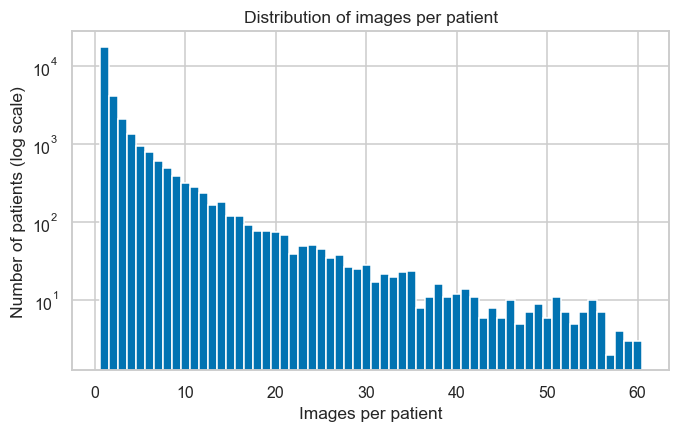

  figure saved -> fig02_pathology_prevalence.png


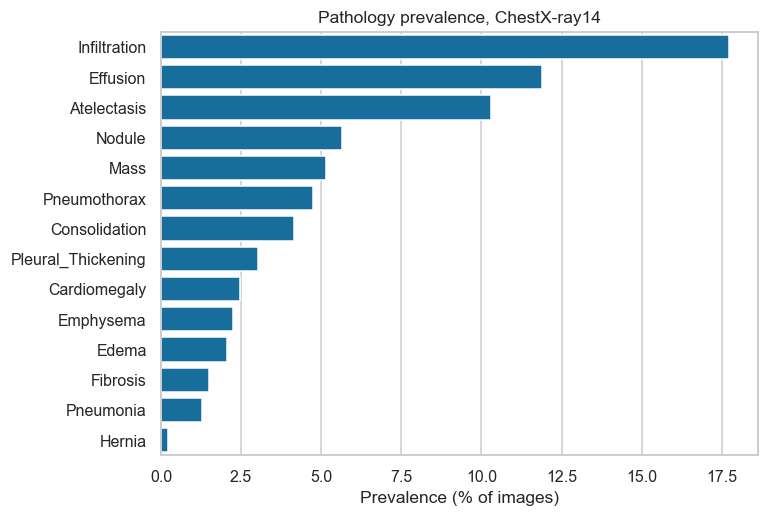

  figure saved -> fig03_label_transition_composition.png


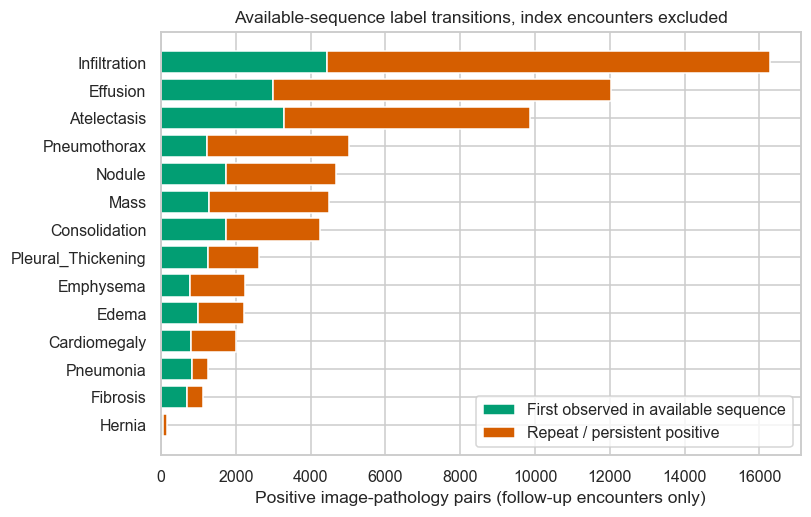

  figure saved -> fig04_prevalence_heatmaps.png


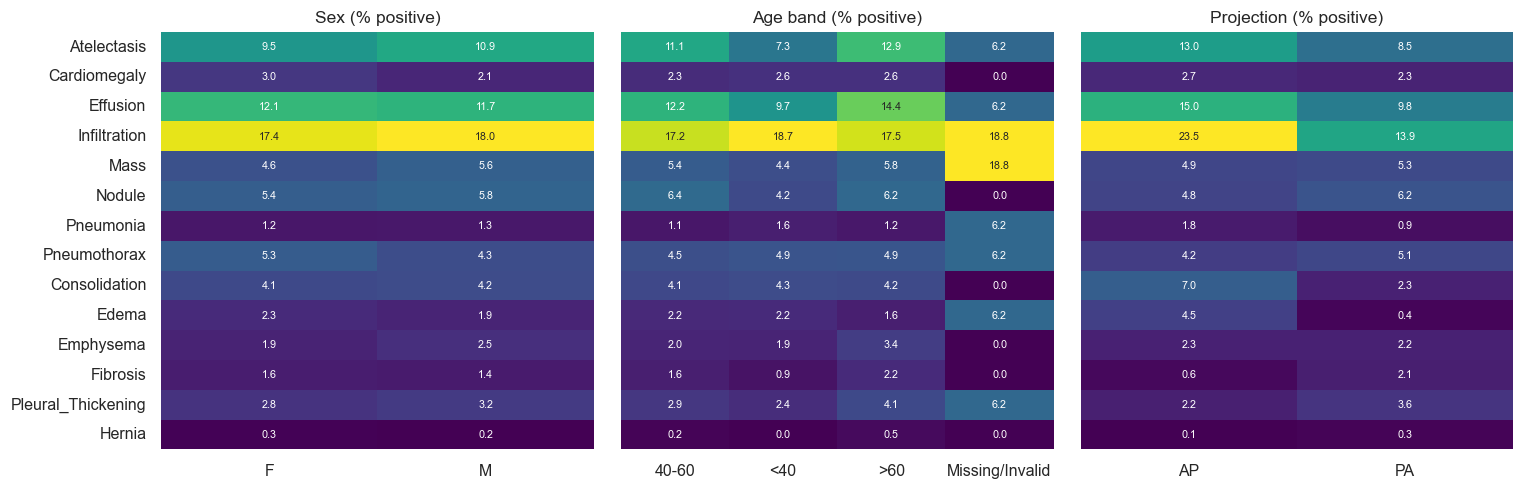

  figure saved -> fig05_sequence_length.png


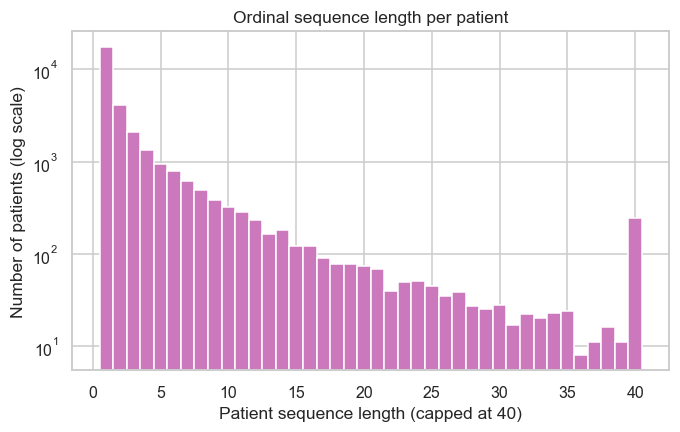

  figure saved -> fig06_sequence_position.png


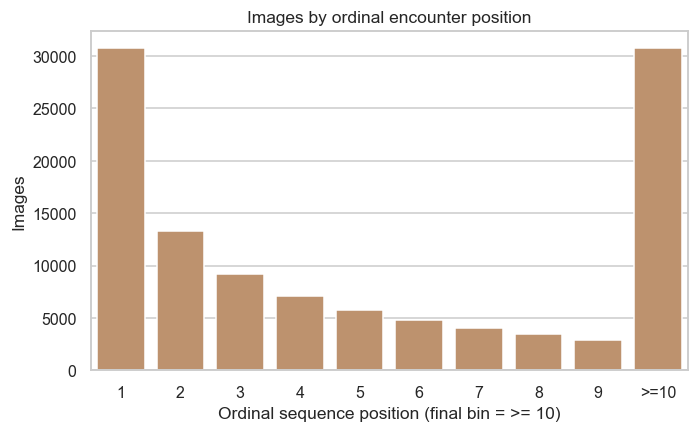

  figure saved -> fig07_followup_quality.png


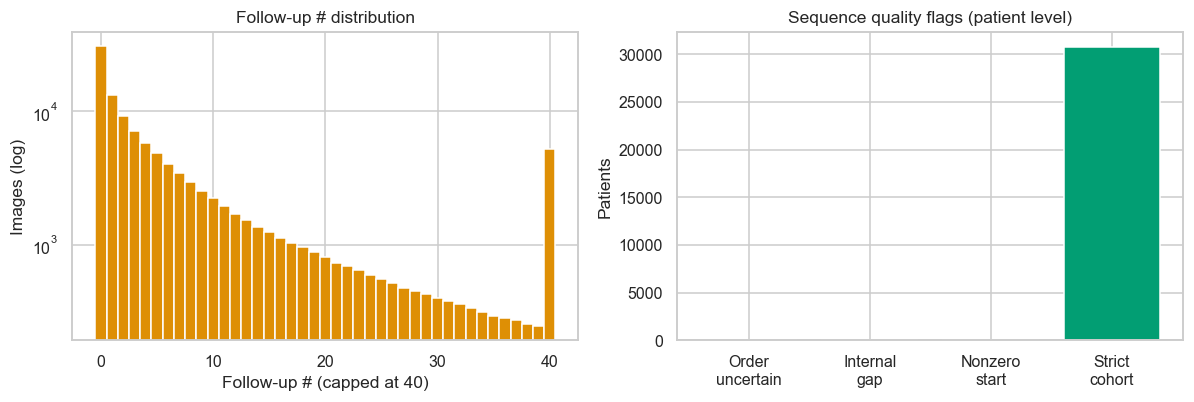

In [17]:
# ---------------------------------- figures ----------------------------------
CB = sns.color_palette("colorblind")

# 1. images per patient
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ipp.values, bins=np.arange(0.5, min(ipp.max(), 60) + 1.5, 1), color=CB[0])
ax.set_yscale("log")
ax.set_xlabel("Images per patient")
ax.set_ylabel("Number of patients (log scale)")
ax.set_title("Distribution of images per patient")
save_figure(fig, "fig01_images_per_patient")
plt.show()

# 2. overall prevalence
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=prev, y="pathology", x="prevalence_pct", color=CB[0], ax=ax)
ax.set_xlabel("Prevalence (% of images)")
ax.set_ylabel("")
ax.set_title("Pathology prevalence, ChestX-ray14")
save_figure(fig, "fig02_pathology_prevalence")
plt.show()

# 3. stacked transition composition (follow-up encounters only)
tp = trans.sort_values("n_positive_followup", ascending=True)
first_n = tp["n_first_observed_followup"].fillna(0).to_numpy()
rep_n = (tp["n_positive_followup"].fillna(0).to_numpy() - first_n)
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh(tp["pathology"], first_n, color=CB[2], label="First observed in available sequence")
ax.barh(tp["pathology"], rep_n, left=first_n, color=CB[3], label="Repeat / persistent positive")
ax.set_xlabel("Positive image-pathology pairs (follow-up encounters only)")
ax.set_title("Available-sequence label transitions, index encounters excluded")
ax.legend(loc="lower right", frameon=True)
save_figure(fig, "fig03_label_transition_composition")
plt.show()

# 4. compact prevalence heatmaps
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), sharey=True)
for ax, tbl, key, title in zip(
        axes, [by_sex, by_age, by_proj],
        ["sex_group", "age_band", "projection_group"], ["Sex", "Age band", "Projection"]):
    m = tbl.set_index(key)[list(PATHOLOGIES)].T
    sns.heatmap(m, cmap="viridis", annot=True, fmt=".1f", cbar=False,
                annot_kws={"size": 7}, ax=ax)
    ax.set_title(f"{title} (% positive)")
    ax.set_xlabel("")
fig.tight_layout()
save_figure(fig, "fig04_prevalence_heatmaps")
plt.show()

# 5. sequence length distribution
fig, ax = plt.subplots(figsize=(7, 4))
sl = df.drop_duplicates("Patient ID")["patient_sequence_length"].clip(upper=40)
ax.hist(sl, bins=np.arange(0.5, 41.5, 1), color=CB[4])
ax.set_yscale("log")
ax.set_xlabel("Patient sequence length (capped at 40)")
ax.set_ylabel("Number of patients (log scale)")
ax.set_title("Ordinal sequence length per patient")
save_figure(fig, "fig05_sequence_length")
plt.show()

# 6. ordinal position distribution
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=pos_dist, x="sequence_position", y="n_images", color=CB[5], ax=ax)
ax.set_xlabel(f"Ordinal sequence position (final bin = >= {SEQUENCE_POSITION_CAP_K})")
ax.set_ylabel("Images")
ax.set_title("Images by ordinal encounter position")
save_figure(fig, "fig06_sequence_position")
plt.show()

# 7. follow-up quality audit
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(df["followup_number_numeric"].dropna().clip(upper=40),
             bins=np.arange(-0.5, 41.5, 1), color=CB[1])
axes[0].set_yscale("log")
axes[0].set_xlabel("Follow-up # (capped at 40)")
axes[0].set_ylabel("Images (log)")
axes[0].set_title("Follow-up # distribution")
qual = pd.Series({
    "Order\nuncertain": df.loc[df["sequence_order_uncertain"], "Patient ID"].nunique(),
    "Internal\ngap": df.loc[df["followup_internal_gap_present"], "Patient ID"].nunique(),
    "Nonzero\nstart": df.loc[df["followup_start_nonzero"], "Patient ID"].nunique(),
    "Strict\ncohort": df.loc[df["strict_history_eligible"], "Patient ID"].nunique(),
})
axes[1].bar(qual.index, qual.values, color=[CB[3], CB[1], CB[4], CB[2]])
axes[1].set_ylabel("Patients")
axes[1].set_title("Sequence quality flags (patient level)")
fig.tight_layout()
save_figure(fig, "fig07_followup_quality")
plt.show()

## 10. Optional image-level visual quality control

Opens a small deterministic sample lazily. Skipped under `FAST_MODE` unless explicitly
enabled, because it is the first step in this notebook that touches pixels.

In [18]:
RUN_VISUAL_QC: bool = (not FAST_MODE)      # set True to force


def display_random_image_qc(frame: pd.DataFrame, n: int = N_VISUAL_QC_IMAGES,
                            seed: int = RANDOM_SEED) -> None:
    """Display `n` randomly sampled linked radiographs with their sequence context."""
    from PIL import Image  # lazy import

    pool = frame[frame["image_exists"]]
    if pool.empty:
        warnings.warn("No linked images available for visual QC.", UserWarning)
        return
    sample = pool.sample(n=min(n, len(pool)), random_state=seed)

    ncol = 4
    nrow = int(np.ceil(len(sample) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.2 * ncol, 3.6 * nrow))
    for ax, (_, row) in zip(np.atleast_1d(axes).ravel(), sample.iterrows()):
        try:
            with Image.open(row["image_path"]) as im:
                ax.imshow(np.asarray(im.convert("L")), cmap="gray")
        except Exception as exc:
            warnings.warn(f"Unreadable image {row['Image Index']}: {exc}", UserWarning)
            ax.text(0.5, 0.5, "unreadable", ha="center", va="center")
        ax.set_title(
            f"{row['Image Index']}\nPt {row['Patient ID']} | FU {row['followup_number_raw']} "
            f"| pos {row['sequence_position_ordinal']} | {row['projection_group']}\n"
            f"{row['Finding Labels'][:44]}", fontsize=7,
        )
        ax.axis("off")
    for ax in np.atleast_1d(axes).ravel()[len(sample):]:
        ax.axis("off")
    fig.tight_layout()
    save_figure(fig, "fig08_visual_qc_sample")
    plt.show()


if RUN_VISUAL_QC:
    warn_if_large_task(N_VISUAL_QC_IMAGES, 0.25, "visual QC image decode")
    display_random_image_qc(df)
else:
    print("Visual QC skipped (FAST_MODE=True). Set RUN_VISUAL_QC = True to run it.")

Visual QC skipped (FAST_MODE=True). Set RUN_VISUAL_QC = True to run it.


## 11. Optional lightweight embedding extraction and caching

Not required by the study design. It exists so later parts can prototype
nearest-neighbour or drift checks without rebuilding a loader.

**Guardrails.** Weights are never downloaded unless `ALLOW_MODEL_DOWNLOAD = True`.
CPU only. The default run is a deterministic 32-image demonstration. Any run above
`MAX_EMBEDDING_IMAGES_WITHOUT_CONFIRMATION` requires `CONFIRM_LARGE_EMBEDDING_RUN = True`.

> **Warning — full-corpus extraction.** Embedding the full corpus on a laptop CPU can
> take many hours and is machine-dependent. Treat it as a resumable offline job, not a
> notebook-default operation, and prefer a GPU if one is available.

**On the choice of backbone.** ImageNet ResNet50 is a computational baseline here, not a
clinically optimised representation. A chest-radiograph-pretrained encoder would be more
defensible for any substantive use, and Part 2 should compare the two if one is available
locally. State the limitation explicitly wherever ImageNet initialisation is used.

In [19]:
RUN_EMBEDDINGS: bool = False           # set True to run the small demonstration
EMBEDDING_PREPROCESSING_VERSION = "cxr-v1-gray3ch-224-imagenetnorm"


def load_backbone(name: str = DEFAULT_BACKBONE, allow_download: bool = ALLOW_MODEL_DOWNLOAD):
    """Lazily construct a CPU feature extractor. Never downloads unless permitted."""
    if not _TORCH_AVAILABLE:
        raise RuntimeError("PyTorch is not installed; embedding extraction unavailable.")
    import torch.nn as nn
    import torchvision

    if name == "resnet50_imagenet":
        if not allow_download:
            raise RuntimeError(
                "Pretrained weights are unavailable. Set ALLOW_MODEL_DOWNLOAD = True or "
                "supply a local checkpoint. Random-weight embeddings are never produced "
                "here, because a cached file of meaningless vectors will eventually be "
                "consumed by Part 2 as though it were real. To test the image pipeline "
                "only, call run_image_loader_smoke_test()."
            )
        model = torchvision.models.resnet50(
            weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2)
        model.fc = nn.Identity()
    elif name == "clip_vit_b32":
        if not allow_download:
            raise RuntimeError("clip_vit_b32 requires ALLOW_MODEL_DOWNLOAD = True or a "
                               "locally cached checkpoint.")
        import clip  # type: ignore
        model, _ = clip.load("ViT-B/32", device="cpu")
    else:
        raise ValueError(f"Unknown backbone {name!r}")

    model.eval()
    return model


if _TORCH_AVAILABLE:
    from torch.utils.data import Dataset

    class CXRImageDataset(Dataset):
        """Lazy grayscale-to-3-channel chest radiograph dataset for CPU inference."""

        def __init__(self, paths: Sequence[str], size: int = 224) -> None:
            from torchvision import transforms
            self.paths = list(paths)
            self.tf = transforms.Compose([
                transforms.Resize((size, size)),
                transforms.Grayscale(num_output_channels=3),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            ])

        def __len__(self) -> int:
            return len(self.paths)

        def __getitem__(self, i: int):
            from PIL import Image
            try:
                with Image.open(self.paths[i]) as im:
                    return self.tf(im.convert("L")), i, True
            except Exception:
                return torch.zeros(3, 224, 224), i, False
else:
    CXRImageDataset = None  # type: ignore


def run_image_loader_smoke_test(frame: pd.DataFrame, n: int = 8,
                                seed: int = RANDOM_SEED) -> Dict[str, object]:
    """Verify the image pipeline decodes and batches correctly. Produces NO cache.

    Use this when pretrained weights are unavailable. It exercises `CXRImageDataset` and
    the DataLoader, reports tensor shape and decode failures, and deliberately returns no
    feature vectors, so nothing meaningless can reach Part 2.
    """
    from torch.utils.data import DataLoader

    pool = frame[frame["image_exists"]]
    sample = pool.sample(n=min(n, len(pool)), random_state=seed)
    ds = CXRImageDataset(sample["image_path"].tolist())
    dl = DataLoader(ds, batch_size=min(CPU_BATCH_SIZE, len(ds)),
                    num_workers=NUM_WORKERS, shuffle=False)
    shapes, failures = [], 0
    for xb, _i, ok in dl:
        shapes.append(tuple(xb.shape))
        failures += int((~np.asarray(ok)).sum())
    result = {"n_images": len(ds), "batch_shapes": shapes, "decode_failures": failures,
              "cache_written": False}
    print(f"  loader smoke test: {result}")
    return result


def extract_embeddings(frame: pd.DataFrame, n: int = DEMO_EMBEDDING_N,
                       backbone: str = DEFAULT_BACKBONE,
                       batch_size: int = CPU_BATCH_SIZE,
                       seed: int = RANDOM_SEED) -> Dict[str, object]:
    """Extract CPU embeddings for a deterministic sample of linked images."""
    from torch.utils.data import DataLoader

    if n > MAX_EMBEDDING_IMAGES_WITHOUT_CONFIRMATION and not CONFIRM_LARGE_EMBEDDING_RUN:
        raise RuntimeError(
            f"n={n:,} exceeds MAX_EMBEDDING_IMAGES_WITHOUT_CONFIRMATION="
            f"{MAX_EMBEDDING_IMAGES_WITHOUT_CONFIRMATION:,}. "
            "Set CONFIRM_LARGE_EMBEDDING_RUN = True to proceed.")

    pool = frame[frame["image_exists"]]
    sample = pool.sample(n=min(n, len(pool)), random_state=seed).reset_index(drop=True)
    warn_if_large_task(len(sample), 0.35, f"{backbone} CPU embedding")

    model = load_backbone(backbone)
    ds = CXRImageDataset(sample["image_path"].tolist())
    dl = DataLoader(ds, batch_size=batch_size, num_workers=NUM_WORKERS, shuffle=False)

    vecs, ok_flags = [], []
    t0 = time.perf_counter()
    with torch.no_grad():
        for xb, _idx, ok in dl:
            vecs.append(model(xb).cpu().numpy())
            ok_flags.append(np.asarray(ok))
    emb = np.concatenate(vecs, axis=0)
    ok_flags = np.concatenate(ok_flags, axis=0)

    return {
        "embeddings": emb,
        "image_ids": sample["Image Index"].to_numpy(),
        "patient_ids": sample["Patient ID"].to_numpy(),
        "sequence_positions": sample["sequence_position_ordinal"].to_numpy(),
        "backbone_id": backbone,
        "pretrained_weights_used": bool(ALLOW_MODEL_DOWNLOAD),
        "preprocessing_version": EMBEDDING_PREPROCESSING_VERSION,
        "dataset_fingerprint": DATASET_FINGERPRINT,
        "extraction_date_utc": datetime.now(timezone.utc).isoformat(),
        "random_seed": seed,
        "n_failures": int((~ok_flags).sum()),
        "runtime_seconds": round(time.perf_counter() - t0, 2),
    }


def save_embedding_cache(cache: Dict[str, object],
                         path: Path = CACHE_DIR / "embeddings_demo.npz") -> Path:
    """Persist embeddings plus full provenance metadata to a .npz file."""
    meta = {k: v for k, v in cache.items()
            if k not in ("embeddings", "image_ids", "patient_ids", "sequence_positions")}
    np.savez_compressed(
        path,
        embeddings=cache["embeddings"], image_ids=cache["image_ids"],
        patient_ids=cache["patient_ids"], sequence_positions=cache["sequence_positions"],
        metadata_json=json.dumps(meta),
    )
    print(f"  embedding cache -> {path} ({path.stat().st_size/1024**2:.2f} MB)")
    return path


def load_embedding_cache(path: Path = CACHE_DIR / "embeddings_demo.npz") -> Dict[str, object]:
    """Load an embedding cache written by `save_embedding_cache`."""
    z = np.load(path, allow_pickle=False)
    out = {k: z[k] for k in ("embeddings", "image_ids", "patient_ids", "sequence_positions")}
    out.update(json.loads(str(z["metadata_json"])))
    return out


DATASET_FINGERPRINT = dataframe_fingerprint(
    df, ["Image Index", "Patient ID", "followup_number_numeric",
         "sequence_position_ordinal", *PATHOLOGIES])
print("Dataset fingerprint:", DATASET_FINGERPRINT)

if RUN_EMBEDDINGS and _TORCH_AVAILABLE:
    if not ALLOW_MODEL_DOWNLOAD:
        print("ALLOW_MODEL_DOWNLOAD is False, so no embeddings are produced. Running the "
              "image loader smoke test instead (no cache is written).")
        run_image_loader_smoke_test(df)
    else:
        with print_runtime_summary("demonstration embedding extraction"):
            cache = extract_embeddings(df, n=DEMO_EMBEDDING_N)
        print(f"  shape={cache['embeddings'].shape}  failures={cache['n_failures']}  "
              f"runtime={cache['runtime_seconds']} s")
        save_embedding_cache(cache)
else:
    print("Embedding extraction skipped. Set RUN_EMBEDDINGS = True to run the "
          f"{DEMO_EMBEDDING_N}-image demonstration (requires ALLOW_MODEL_DOWNLOAD = True).")

Dataset fingerprint: ff1425a899795ae61e5aa36ca2ec36252ed995de
Embedding extraction skipped. Set RUN_EMBEDDINGS = True to run the 32-image demonstration (requires ALLOW_MODEL_DOWNLOAD = True).


## 12. Save artifacts and Part 1 audit checklist

In [20]:
with print_runtime_summary("persist analysis artifacts"):
    wide_path = CACHE_DIR / "part1_image_level.parquet"
    long_path = CACHE_DIR / "part1_transition_long.parquet"
    try:
        df.to_parquet(wide_path, index=False)
        long_df.to_parquet(long_path, index=False)
        fmt = "parquet"
    except Exception as exc:
        warnings.warn(f"Parquet unavailable ({exc}); falling back to compressed CSV. "
                      "Install pyarrow for faster reloads.", UserWarning)
        wide_path = CACHE_DIR / "part1_image_level.csv.gz"
        long_path = CACHE_DIR / "part1_transition_long.csv.gz"
        df.to_csv(wide_path, index=False)
        long_df.to_csv(long_path, index=False)
        fmt = "csv.gz"
    print(f"  wide table -> {wide_path.name} ({wide_path.stat().st_size/1024**2:.1f} MB)")
    print(f"  long table -> {long_path.name} ({long_path.stat().st_size/1024**2:.1f} MB)")

RUN_MANIFEST.update({
    "artifact_format": fmt,
    "wide_rows": int(len(df)),
    "long_rows": int(len(long_df)),
    "dataset_fingerprint": DATASET_FINGERPRINT,
    "long_fingerprint": dataframe_fingerprint(
        long_df, ["Image Index", "pathology", "label_current"]),
    "tables_saved": sorted(_SAVED_TABLES),
    "figures_saved": sorted(_SAVED_FIGURES),
    "pathologies": list(PATHOLOGIES),
    "redundancy_definitions": list(REDUNDANCY_DEFINITIONS),
})
(LOGS_DIR / "part1_run_manifest.json").write_text(json.dumps(RUN_MANIFEST, indent=2))
print(f"  manifest   -> {LOGS_DIR/'part1_run_manifest.json'}")

[start] persist analysis artifacts
  wide table -> part1_image_level.parquet (2.8 MB)
  long table -> part1_transition_long.parquet (13.0 MB)
[done ] persist analysis artifacts  (2.3 s)
  manifest   -> C:\Users\kruta\Downloads\part1_outputs\logs\part1_run_manifest.json


In [21]:
# ----------------------------- audit checklist -------------------------------
REQUIRED_TABLES = [
    "data_coverage_report.csv", "metadata_missingness.csv", "label_integrity_audit.csv",
    "overall_pathology_prevalence.csv", "pathology_prevalence_by_sex.csv",
    "pathology_prevalence_by_age_band.csv", "pathology_prevalence_by_projection.csv",
    "images_per_patient_summary.csv", "patient_sequence_summary.csv",
    "followup_number_audit.csv", "followup_structure_audit.csv",
    "sequence_quality_audit.csv", "pathology_transition_summary.csv",
    "pathology_transition_summary_strict_cohort.csv",
    "sequence_position_distribution.csv", "random_patient_sequence_audit.csv",
]
REQUIRED_FIGURES = [f"fig0{i}" for i in range(1, 8)]

link_rate = 100 * float(df["image_exists"].mean())
fu_rate = 100 * float((~df["followup_number_missing"]).mean())
dup_fu = int(df["duplicate_patient_followup"].sum())
missing_tabs = [t for t in REQUIRED_TABLES if t not in _SAVED_TABLES]
missing_figs = [f for f in REQUIRED_FIGURES
                if not any(s.startswith(f) for s in _SAVED_FIGURES)]

checks = [
    ("metadata located", "PASS" if META_PATH.exists() else "FAIL", META_PATH.name),
    ("image index built",
     "PASS" if len(image_index) > 0 else "FAIL", f"{len(image_index):,} files"),
    ("metadata-image linkage rate",
     "PASS" if link_rate >= 99.0 else ("WARN" if link_rate >= 90 else "FAIL"),
     f"{link_rate:.2f}%"),
    ("label parsing completed",
     "PASS" if bool(df["label_parse_ok"].all()) else "WARN",
     f"{int((~df['label_parse_ok']).sum()):,} rows flagged"),
    ("pathology columns present",
     "PASS" if all(p in df.columns for p in PATHOLOGIES) else "FAIL",
     f"{len(PATHOLOGIES)} columns"),
    ("No Finding kept as indicator only",
     "PASS" if ("no_finding_label" in df.columns and NO_FINDING_TOKEN not in df.columns)
     else "FAIL", "not a 15th target"),
    ("patient IDs present",
     "PASS" if not bool(df["patient_id_missing"].any()) else "FAIL",
     f"{df['Patient ID'].nunique():,} patients"),
    ("follow-up parse rate",
     "PASS" if fu_rate >= 99.9 else "WARN", f"{fu_rate:.3f}%"),
    ("duplicate (patient, follow-up) rows",
     "PASS" if dup_fu == 0 else "WARN", f"{dup_fu:,} rows"),
    ("patient sequences built",
     "PASS" if "sequence_position_ordinal" in df.columns else "FAIL",
     f"max length {int(df['patient_sequence_length'].max())}"),
    ("serial transition table built",
     "PASS" if len(long_df) == len(df) * len(PATHOLOGIES) else "FAIL",
     f"{len(long_df):,} rows"),
    ("index encounters flagged separately",
     "PASS" if "is_index_encounter" in long_df.columns else "FAIL",
     f"{int(df['is_index_encounter'].sum()):,} index encounters"),
    ("required tables saved",
     "PASS" if not missing_tabs else "FAIL", f"missing: {missing_tabs or 'none'}"),
    ("required figures saved",
     "PASS" if not missing_figs else "FAIL", f"missing: {missing_figs or 'none'}"),
    ("history computed on eligible cohort only",
     "PASS" if bool((long_df.loc[~long_df["history_available"],
                                 "label_ever_prior"].isna()).all()) else "FAIL",
     f"{int(long_df['history_available'].sum()):,} rows with history"),
    ("internal gap distinct from nonzero start",
     "PASS" if {"followup_internal_gap_present", "followup_start_nonzero"}
     <= set(df.columns) else "FAIL",
     f"{df.loc[df['followup_internal_gap_present'], 'Patient ID'].nunique():,} gapped, "
     f"{df.loc[df['followup_start_nonzero'], 'Patient ID'].nunique():,} nonzero-start"),
    ("strict sensitivity cohort available",
     "PASS" if "strict_history_eligible" in df.columns else "FAIL",
     f"{df.loc[df['strict_history_eligible'], 'Patient ID'].nunique():,} patients"),
    ("alert-burden schema defined",
     "PASS" if len(REDUNDANCY_DEFINITIONS) == 4 else "FAIL",
     "label + prediction families"),
    ("optional embedding cache",
     "PASS" if (CACHE_DIR / "embeddings_demo.npz").exists() else "SKIP",
     "optional in Part 1"),
]
checklist = pd.DataFrame(checks, columns=["check", "status", "detail"])
print(checklist.to_string(index=False))
save_table(checklist, "part1_audit_checklist")

n_fail = int((checklist["status"] == "FAIL").sum())
n_warn = int((checklist["status"] == "WARN").sum())
print(f"\n{'=' * 72}")
print(f"PART 1 RESULT: {n_fail} FAIL, {n_warn} WARN, "
      f"{int((checklist['status'] == 'PASS').sum())} PASS")
print("Resolve every FAIL before starting Part 2." if n_fail
      else "No blocking failures. Part 1 artifacts are ready for Part 2.")
print("=" * 72)
gc.collect()

                                   check status                      detail
                        metadata located   PASS         Data_Entry_2017.csv
                       image index built   PASS               112,120 files
             metadata-image linkage rate   PASS                     100.00%
                 label parsing completed   PASS              0 rows flagged
               pathology columns present   PASS                  14 columns
       No Finding kept as indicator only   PASS           not a 15th target
                     patient IDs present   PASS             30,805 patients
                    follow-up parse rate   PASS                    100.000%
     duplicate (patient, follow-up) rows   PASS                      0 rows
                 patient sequences built   PASS              max length 184
           serial transition table built   PASS              1,569,680 rows
     index encounters flagged separately   PASS     30,805 index encounters
            

32576

## 13. Reproducibility, limitations, and design safeguards

### 13.1 Reproducibility

Seeds are set for `random`, NumPy and PyTorch. All sorting uses stable mergesort with an
explicit tie-breaker, so ordinal positions are deterministic across runs and platforms.
`part1_run_manifest.json` records the library versions, the metadata file fingerprint,
and SHA1 fingerprints of both output tables, so Part 2 can assert it received exactly
what Part 1 produced.

### 13.2 Limitations carried forward

1. **No calendar time.** `Follow-up #` is ordinal. Nothing per unit time is estimable.
2. **Weak labels.** NLP extractions from reports, not adjudicated image findings. Label
   instability between adjacent encounters is indistinguishable from clinical change and
   will inflate the actionable-new category.
3. **Truncated sequences.** Imaging before the first available study, or at another
   institution, is invisible. "First observed in the available sequence" is an upper
   bound on first presentation, and its bias is concentrated at ordinal position 1.
   A nonzero starting Follow-up # is flagged as possible left truncation; it is reported
   separately from an internal numbering gap, which is a different condition.
4. **Index encounters are degenerate.** Redundancy is undefined at position 1. Every
   redundancy quantity is computed on follow-up encounters only.
5. **Heavy-imager dominance.** A minority of patients supplies a large share of images
   and is systematically sicker. Per-image and per-patient results will differ.
6. **Acquisition context is not demographic.** PA and AP populations differ in prevalence
   and in care setting. Projection is reported, never silently adjusted away.
7. **Single institution, single label pipeline.** No external cohort is available in this
   design, so nothing here speaks to transportability.
8. **Simulation only.** No clinician saw any of these alerts. Nothing here measures
   workload, trust, override behaviour, or outcome.

### 13.3 Safeguards built into the code

- No row is ever dropped silently; exclusions are flagged with an explicit reason.
- Implausible ages and contradictory labels are flagged, never rewritten.
- Duplicate `(Image Index, pathology)` predictions raise rather than double-count.
- `validate_prediction_schema` runs before any join in Part 2.
- The official split is verified patient-disjoint rather than assumed.
- Two redundancy families are defined so that no deployable claim rests on oracle history.
- History is computed only over the eligible cohort, so unparseable follow-up numbers
  never enter a shift or cumsum window; ineligible rows carry null history, not a default.
- Internal numbering gaps are computed relative to each patient's own observed minimum
  and maximum, never by assuming every sequence starts at zero.
- The third alert category is named `first_observed_positive_alert` in code; the
  "actionable-new" shorthand exists only as a reporting alias.
- Random-weight embeddings cannot be produced or cached; the loader smoke test is separate.
- Full-corpus embedding extraction is gated behind an explicit confirmation flag.

### 13.4 Leakage risks that Part 2 must handle

- **Patient-level splitting is mandatory.** Multiple images per patient make image-level
  splits leak. Use `official_split` after the disjointness check, or split on `Patient ID`.
- **History features leak the target.** If any sequence-history variable is ever fed to
  the model, it must be computed strictly from encounters at earlier ordinal positions.
  In this design the model sees a single image and history is applied only post hoc,
  which is the safest arrangement.
- **Threshold selection must happen on the development split**, then be locked before the
  held-out split is touched once.

In [22]:
seq = df.sort_values(["Patient ID", "sequence_position_ordinal"])
d = seq.groupby("Patient ID")["age_numeric"].diff()
pt = seq.assign(d=d).groupby("Patient ID").agg(
    n=("Image Index", "size"), min_step=("d", "min"), max_step=("d", "max"))
multi = pt[pt["n"] > 1]
print(f"patients with >1 image: {len(multi):,}")
print(f"  any age decrease      : {(multi['min_step'] < 0).mean()*100:.1f}%")
print(f"  decrease >2 years     : {(multi['min_step'] < -2).mean()*100:.1f}%")
print(f"  decrease >10 years    : {(multi['min_step'] < -10).mean()*100:.1f}%")
print(f"  any increase >10 years: {(multi['max_step'] > 10).mean()*100:.1f}%")

patients with >1 image: 13,302
  any age decrease      : 26.3%
  decrease >2 years     : 12.6%
  decrease >10 years    : 2.2%
  any increase >10 years: 0.3%
